# Mount


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Cell 1: Import semua library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io
import os
import glob

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, MinMaxScaler, RobustScaler

# Untuk Random Forest
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [5]:
input_folder = '/content/drive/MyDrive/tga_anisa/'

# Combine Data


In [6]:
if not os.path.exists(input_folder):
    print(f"❌ Folder tidak ditemukan: {input_folder}")
    print("Pastikan path benar dan Drive sudah di-mount.")
else:
    # 4. Ambil semua file CSV
    all_files = glob.glob(os.path.join(input_folder, "*.csv"))
    print(f"✅ Ditemukan {len(all_files)} file CSV.")

    # 5. Baca dan gabungkan semua file
    df_list = []
    for file in all_files:
        temp_df = pd.read_csv(file)
        temp_df['source_file'] = os.path.basename(file)   # opsional: lacak asal file
        df_list.append(temp_df)

    df = pd.concat(df_list, ignore_index=True)
    print(f"📊 Total data setelah digabung: {df.shape[0]} baris x {df.shape[1]} kolom")

    # 6. Bersihkan kolom kosong (misal: kolom hasil koma ganda seperti ",,label")
    # Hapus kolom yang semua nilainya NaN
    df = df.dropna(axis=1, how='all')
    # Hapus kolom bernama 'Unnamed: ...' yang muncul dari koma berlebih
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

    # 7. Urutkan berdasarkan timestamp (prioritas: epoch_ms -> ts_millis -> date+time)
    if 'epoch_ms' in df.columns:
        df = df.sort_values(by='epoch_ms').reset_index(drop=True)
        print("📈 Data diurutkan berdasarkan kolom 'epoch_ms'.")
    elif 'ts_millis' in df.columns:
        df = df.sort_values(by='ts_millis').reset_index(drop=True)
        print("📈 Data diurutkan berdasarkan kolom 'ts_millis'.")
    elif 'date' in df.columns and 'time' in df.columns:
        df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'])
        df = df.sort_values(by='datetime').reset_index(drop=True)
        print("📈 Data diurutkan berdasarkan gabungan 'date' + 'time'.")
    else:
        print("⚠️ Tidak ada kolom waktu yang dikenali. Data tidak diurutkan.")

    # 8. Tampilkan cuplikan hasil
    print("\n🔍 5 baris pertama setelah penggabungan & pengurutan:")
    display(df.head())

    # 9. Tampilkan informasi kolom
    print("\n📋 Tipe data setiap kolom:")
    print(df.dtypes)

✅ Ditemukan 15 file CSV.
📊 Total data setelah digabung: 32009 baris x 28 kolom
📈 Data diurutkan berdasarkan kolom 'epoch_ms'.

🔍 5 baris pertama setelah penggabungan & pengurutan:


,subject_id,nama,date,time,epoch_ms,ts_millis,ax1,ay1,az1,gx1,...,label,source_file,datetime,mpu_id,ax,ay,az,gx,gy,gz
0,NaN,NaN,NaN,NaN,1.182281e+09,786130.0,NaN,NaN,NaN,NaN,...,ergonomis,alifi.csv,2026-05-20 17:39:01.130,2.0,0.90381,-0.50586,0.00171,2.817,-1.115,-0.015
1,NaN,NaN,NaN,NaN,1.182281e+09,786130.0,NaN,NaN,NaN,NaN,...,ergonomis,alifi.csv,2026-05-20 17:39:01.130,1.0,0.97583,-0.10889,0.47021,4.557,2.489,0.473
2,NaN,NaN,NaN,NaN,1.182281e+09,785530.0,NaN,NaN,NaN,NaN,...,ergonomis,alifi.csv,2026-05-20 17:39:01.530,1.0,0.93384,-0.10181,0.55029,6.504,-21.641,7.527
3,NaN,NaN,NaN,NaN,1.182281e+09,785530.0,NaN,NaN,NaN,NaN,...,ergonomis,alifi.csv,2026-05-20 17:39:01.530,2.0,0.87378,-0.54907,-0.00513,12.595,6.985,-3.611
4,NaN,NaN,NaN,NaN,1.182281e+09,785730.0,NaN,NaN,NaN,NaN,...,ergonomis,alifi.csv,2026-05-20 17:39:01.730,1.0,0.94409,-0.10620,0.52881,5.840,-14.130,4.130



📋 Tipe data setiap kolom:
subject_id      object
nama            object
date            object
time            object
epoch_ms       float64
ts_millis      float64
ax1            float64
ay1            float64
az1            float64
gx1            float64
gy1            float64
gz1            float64
ax2            float64
ay2            float64
az2            float64
gx2            float64
gy2            float64
gz2            float64
label           object
source_file     object
datetime        object
mpu_id         float64
ax             float64
ay             float64
az             float64
gx             float64
gy             float64
gz             float64
dtype: object


 # EDA

In [7]:
# Cell EDA 1: Informasi umum dataset
print("="*50)
print("1. INFORMASI UMUM DATASET")
print("="*50)
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")
print("\nNama kolom:")
print(df.columns.tolist())

print("\n" + "="*50)
print("2. STATISTIK DESKRIPTIF (KOLOM NUMERIK)")
print("="*50)
display(df.describe())

print("\n" + "="*50)
print("3. STATISTIK KOLOM KATEGORIK")
print("="*50)
display(df.describe(include=['object']))

1. INFORMASI UMUM DATASET
Jumlah baris: 32009
Jumlah kolom: 28

Nama kolom:
['subject_id', 'nama', 'date', 'time', 'epoch_ms', 'ts_millis', 'ax1', 'ay1', 'az1', 'gx1', 'gy1', 'gz1', 'ax2', 'ay2', 'az2', 'gx2', 'gy2', 'gz2', 'label', 'source_file', 'datetime', 'mpu_id', 'ax', 'ay', 'az', 'gx', 'gy', 'gz']

2. STATISTIK DESKRIPTIF (KOLOM NUMERIK)


,epoch_ms,ts_millis,ax1,ay1,az1,gx1,gy1,gz1,ax2,ay2,...,gx2,gy2,gz2,mpu_id,ax,ay,az,gx,gy,gz
count,3.200900e+04,3.200900e+04,10615.000000,10607.000000,10613.000000,10611.000000,10594.000000,10570.000000,10615.000000,10615.000000,...,10600.000000,10605.000000,10604.000000,21394.000000,21394.000000,21374.000000,21390.000000,21360.000000,21354.000000,21349.000000
mean,1.703608e+09,7.042029e+05,0.969170,0.035176,0.247988,-1.788122,0.275747,-0.093405,0.941335,0.208270,...,-1.016545,0.984293,1.320838,1.499953,0.849307,-0.094178,0.406847,-0.616573,1.063420,0.009602
std,4.609439e+08,3.757803e+05,0.064346,0.077533,0.130479,4.184672,6.950135,2.503354,0.032040,0.101435,...,5.601660,5.491561,3.168562,0.500012,0.191166,0.229695,0.396960,4.084285,3.893539,2.230325
min,1.182281e+09,1.254370e+05,0.482420,-0.291500,-0.176270,-48.893000,-81.366000,-25.588000,-0.741210,-0.263430,...,-120.267000,-89.458000,-73.710000,1.000000,-0.270260,-0.749760,-0.907230,-125.450000,-96.817000,-110.611000
25%,1.267572e+09,3.876050e+05,0.939940,-0.031980,0.185550,-2.603000,-0.450000,-0.695000,0.928710,0.120730,...,-2.061000,0.183000,0.733000,1.000000,0.813720,-0.155210,0.070560,-1.786000,0.122000,-0.687000
50%,1.435314e+09,5.425710e+05,0.977290,0.034420,0.254390,-1.771000,0.370000,-0.107000,0.944820,0.230710,...,-0.939000,1.061000,1.344000,1.000000,0.894655,-0.066890,0.429690,-0.588000,0.969000,0.092000
75%,2.207323e+09,1.013789e+06,1.004390,0.103760,0.325440,-0.885000,1.206000,0.458000,0.960450,0.277100,...,0.198000,1.985000,1.931000,2.000000,0.994380,0.079590,0.758540,0.580000,1.977000,0.702000
max,2.216382e+09,1.652398e+06,1.263430,0.337160,0.864010,44.824000,82.603000,25.733000,1.210450,0.540040,...,109.939000,83.855000,70.786000,2.000000,1.516850,1.615230,1.122800,170.595000,243.275000,78.969000



3. STATISTIK KOLOM KATEGORIK


,subject_id,nama,date,time,label,source_file,datetime
count,10615,10615,10615,10615,32009,32009,21394
unique,8,8,3,10615,2,15,10697
top,SUBJ007,nisa,2026-05-23,16:35:29.936000,ergonomis,alifi.csv,2026-05-20 17:52:24.898
freq,1500,1500,5456,1,17352,7119,3


## Missing Values

MISSING VALUES PER KOLOM


,Missing Values,Persentase (%)
gz1,21439,66.978037
gy1,21415,66.903059
gx2,21409,66.884314
gz2,21405,66.871817
gy2,21404,66.868693
ay1,21402,66.862445
gx1,21398,66.849948
az1,21396,66.843700
time,21394,66.837452
date,21394,66.837452



⚠️ Ada missing values. Perlu ditangani pada tahap cleaning.


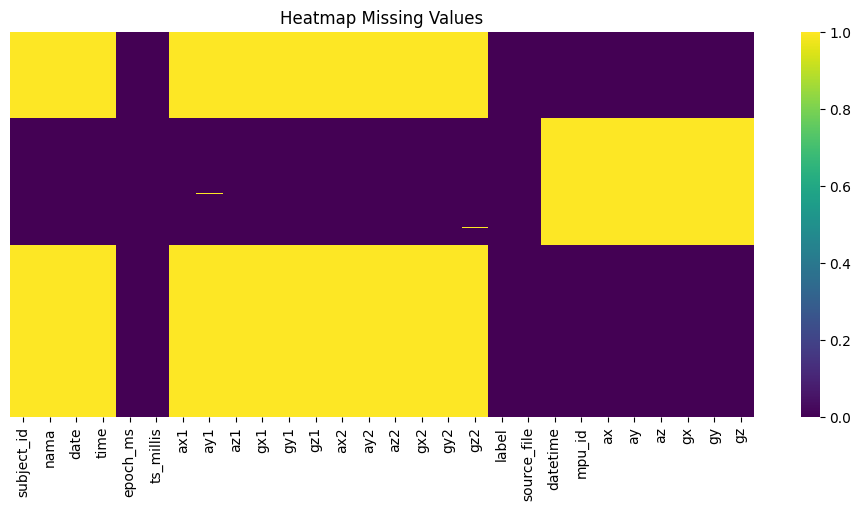

In [8]:
# Cell EDA 2: Analisis missing values
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_table = pd.DataFrame({
    'Missing Values': missing,
    'Persentase (%)': missing_percent
}).sort_values(by='Persentase (%)', ascending=False)

print("="*50)
print("MISSING VALUES PER KOLOM")
print("="*50)
display(missing_table[missing_table['Missing Values'] > 0])

if missing_table['Missing Values'].sum() == 0:
    print("\n✅ Tidak ada missing values dalam dataset.")
else:
    print("\n⚠️ Ada missing values. Perlu ditangani pada tahap cleaning.")

# Visualisasi missing values heatmap (jika ada)
if missing_table['Missing Values'].sum() > 0:
    plt.figure(figsize=(12, 5))
    sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis')
    plt.title('Heatmap Missing Values')
    plt.show()

## Distribusi dan Outlier

Kolom numerik yang ditemukan: ['epoch_ms', 'ts_millis', 'ax1', 'ay1', 'az1', 'gx1', 'gy1', 'gz1', 'ax2', 'ay2', 'az2', 'gx2', 'gy2', 'gz2', 'mpu_id', 'ax', 'ay', 'az', 'gx', 'gy', 'gz']


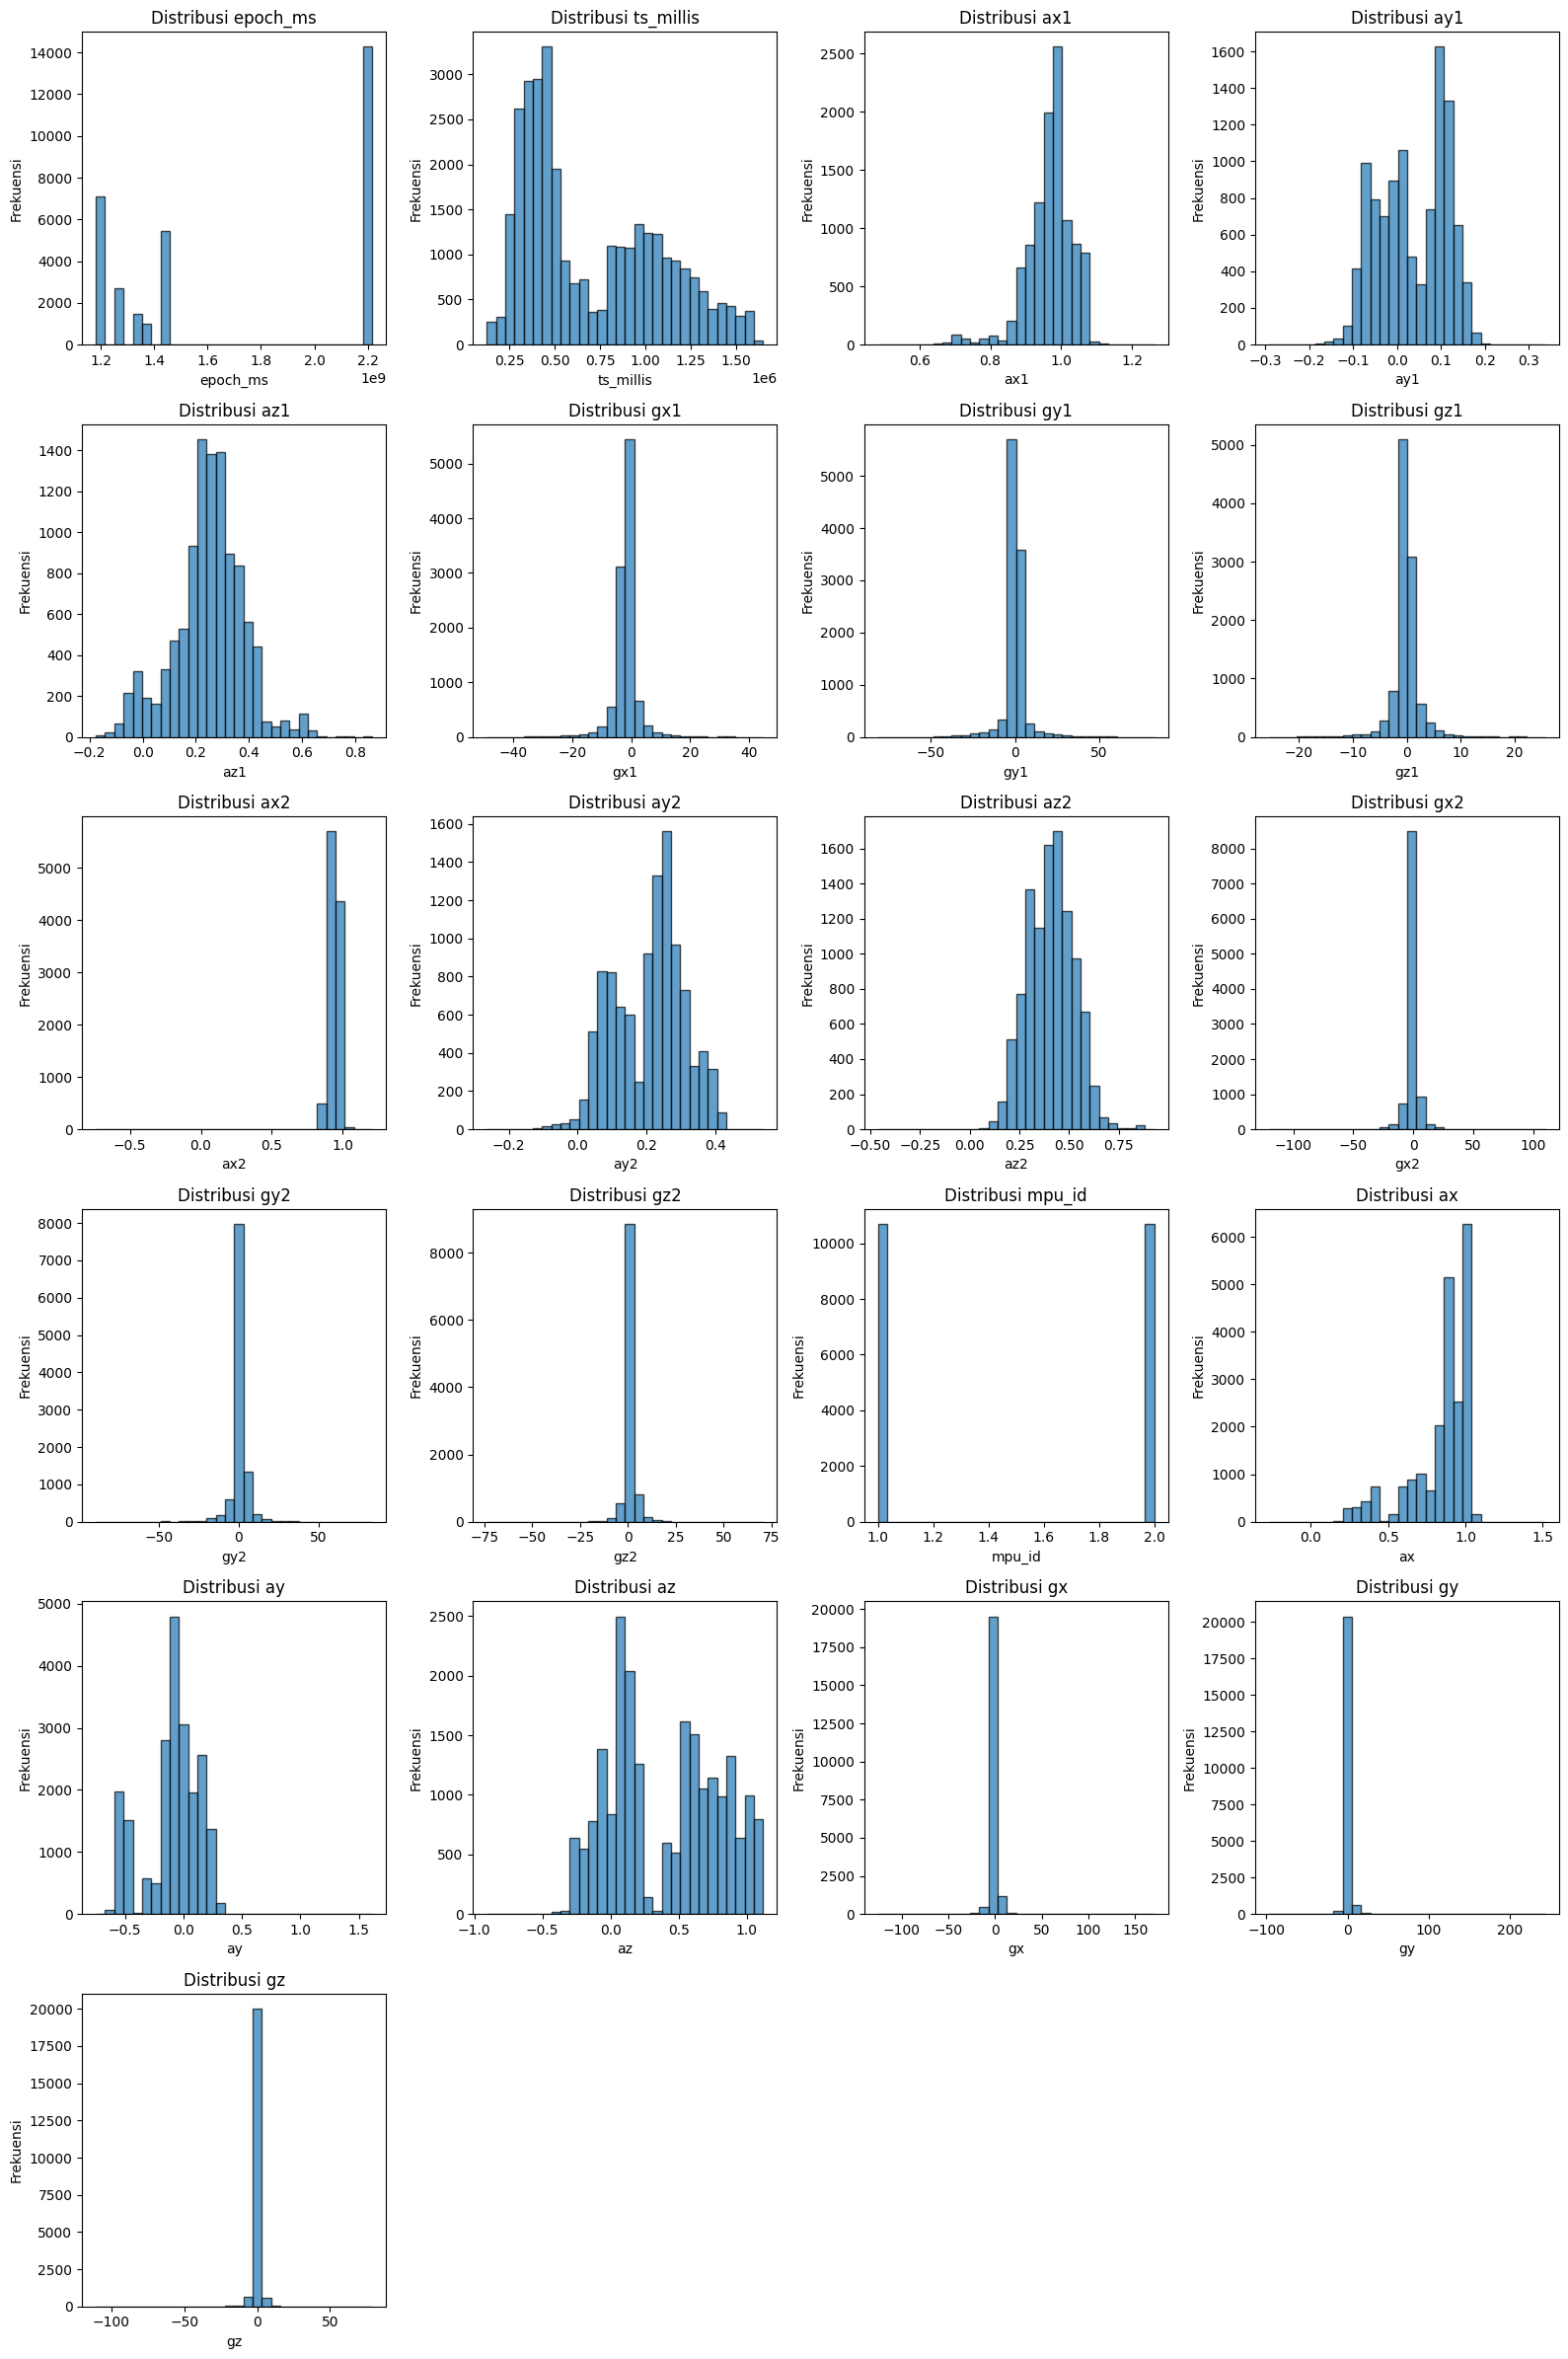

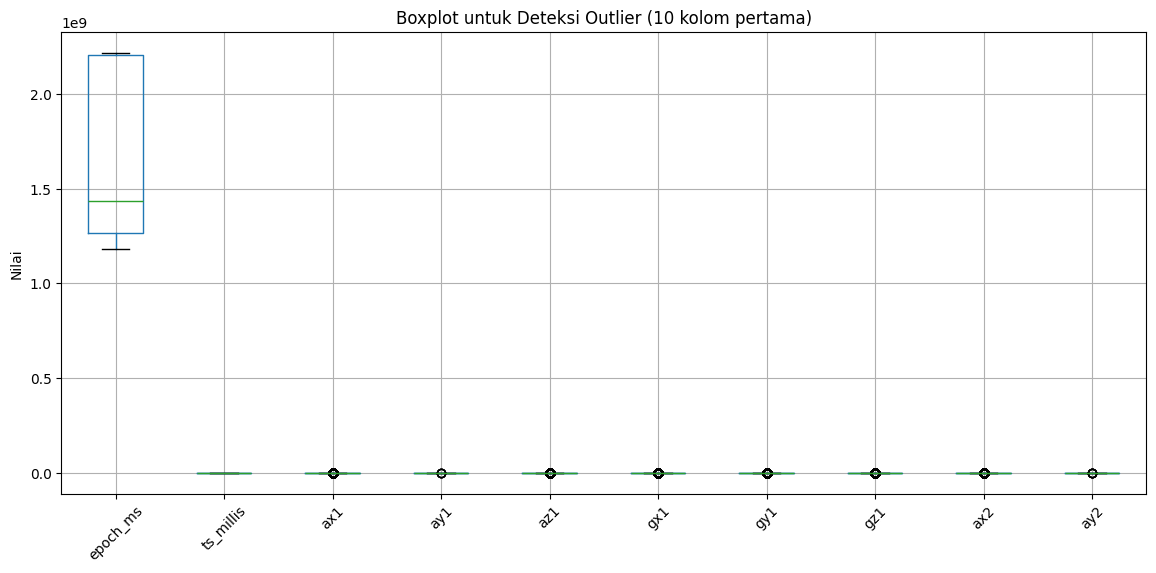

In [9]:
# Cell EDA 3: Distribusi dan outlier pada kolom numerik
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Kolom numerik yang ditemukan:", num_cols)

if len(num_cols) > 0:
    # Histogram untuk semua kolom numerik
    n_cols = len(num_cols)
    n_rows = (n_cols + 3) // 4  # atur layout 4 kolom per baris
    fig, axes = plt.subplots(n_rows, 4, figsize=(16, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols > 0 else []

    for i, col in enumerate(num_cols):
        axes[i].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
        axes[i].set_title(f'Distribusi {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frekuensi')

    # Hapus subplot kosong
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

    # Boxplot untuk deteksi outlier (maksimal 10 kolom)
    cols_to_plot = num_cols[:10] if len(num_cols) > 10 else num_cols
    plt.figure(figsize=(14, 6))
    df[cols_to_plot].boxplot(rot=45)
    plt.title('Boxplot untuk Deteksi Outlier (10 kolom pertama)')
    plt.ylabel('Nilai')
    plt.show()
else:
    print("Tidak ada kolom numerik.")

## Korelasi Antar Fitur

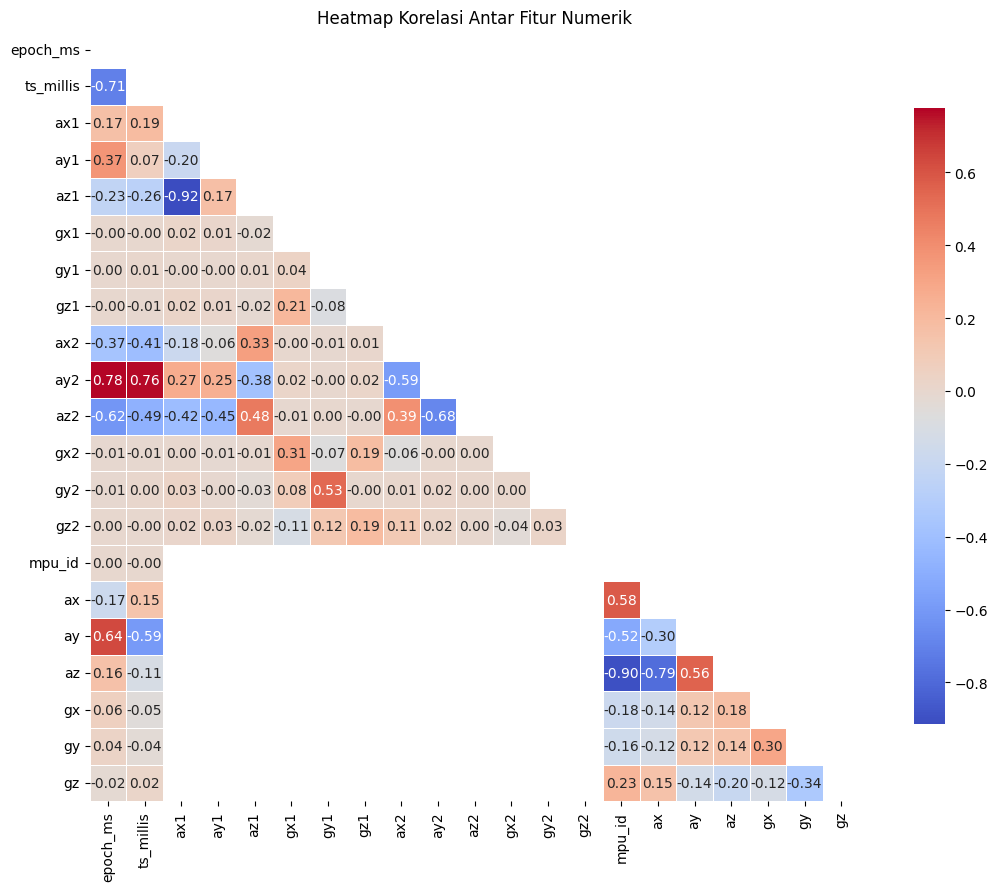


⚠️ Pasangan fitur dengan korelasi sangat tinggi (>|0.9|):
   ax1 & az1 : -0.915


In [10]:
# Cell EDA 4: Heatmap korelasi (hanya kolom numerik)
num_cols = df.select_dtypes(include=np.number).columns.tolist()
if len(num_cols) > 1:
    corr = df[num_cols].corr()
    plt.figure(figsize=(14, 10))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt='.2f',
                linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
    plt.title('Heatmap Korelasi Antar Fitur Numerik')
    plt.show()

    # Cari pasangan fitur dengan korelasi tinggi (>0.9 atau <-0.9)
    high_corr = []
    for i in range(len(corr.columns)):
        for j in range(i+1, len(corr.columns)):
            if abs(corr.iloc[i, j]) > 0.9:
                high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))
    if high_corr:
        print("\n⚠️ Pasangan fitur dengan korelasi sangat tinggi (>|0.9|):")
        for pair in high_corr:
            print(f"   {pair[0]} & {pair[1]} : {pair[2]:.3f}")
    else:
        print("\n✅ Tidak ada pasangan fitur dengan korelasi >|0.9|.")
else:
    print("Tidak cukup kolom numerik untuk korelasi.")


## Analisi Variabel Target

ANALISIS TARGET: 'label'
Jumlah unik value: 2

Value counts:
label
ergonomis        17352
non-ergonomis    14657
Name: count, dtype: int64


/tmp/ipykernel_3467/622614518.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[target_col], order=df[target_col].value_counts().index, palette='Set2')


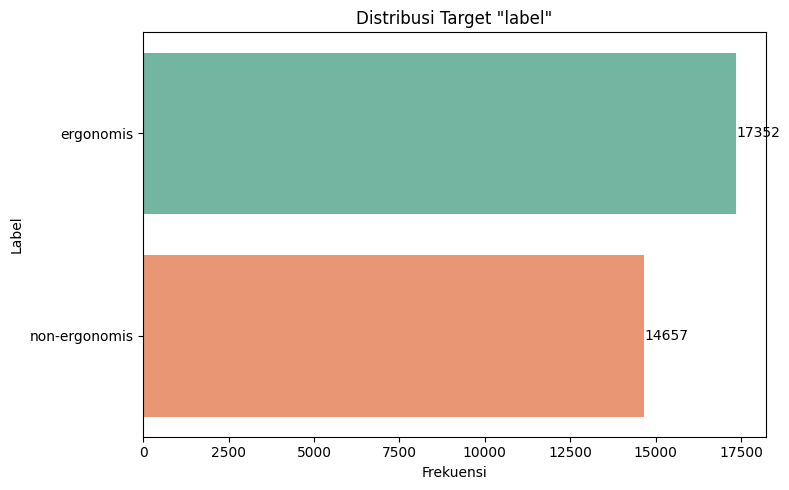


Rasio kelas minoritas/mayoritas: 0.845
✅ Dataset cukup seimbang.


In [11]:
# Cell EDA 5: Analisis target (kolom 'label')
target_col = 'label'  # sesuai dengan data Anda

if target_col in df.columns:
    print("="*50)
    print(f"ANALISIS TARGET: '{target_col}'")
    print("="*50)

    print("Jumlah unik value:", df[target_col].nunique())
    print("\nValue counts:")
    print(df[target_col].value_counts())

    # Visualisasi distribusi target
    plt.figure(figsize=(8, 5))
    sns.countplot(y=df[target_col], order=df[target_col].value_counts().index, palette='Set2')
    plt.title(f'Distribusi Target "{target_col}"')
    plt.xlabel('Frekuensi')
    plt.ylabel('Label')
    for i, v in enumerate(df[target_col].value_counts().values):
        plt.text(v + 2, i, str(v), va='center')
    plt.tight_layout()
    plt.show()

    # Cek apakah target seimbang (untuk klasifikasi)
    counts = df[target_col].value_counts()
    min_class = counts.min()
    max_class = counts.max()
    imbalance_ratio = min_class / max_class
    print(f"\nRasio kelas minoritas/mayoritas: {imbalance_ratio:.3f}")
    if imbalance_ratio < 0.2:
        print("⚠️ Dataset tidak seimbang (imbalance). Pertimbangkan teknik resampling nanti.")
    else:
        print("✅ Dataset cukup seimbang.")
else:
    print(f"Kolom target '{target_col}' tidak ditemukan. Silakan cek nama kolom.")

# Cleaning Data

## Handle Missing Values & Hapus Kolom Non-Fitur

In [12]:
# Cell Cleaning 1: Tangani missing values dan hapus kolom yang tidak diperlukan
df_clean = df.copy()

# 1. Hapus kolom yang tidak diperlukan (identitas, waktu, metadata)
# Keep 'source_file' because it's needed for LOPO splitting
cols_to_drop = ['subject_id', 'nama', 'date', 'time', 'epoch_ms', 'ts_millis', 'datetime','mpu_id']
cols_exist = [c for c in cols_to_drop if c in df_clean.columns]
df_clean.drop(columns=cols_exist, inplace=True)
print(f"Kolom yang dihapus: {cols_exist}")
print(f"Kolom tersisa: {df_clean.columns.tolist()}")

# 2. Tangani missing values
print("\nMissing values sebelum handling:")
print(df_clean.isnull().sum())

# Identify numerical columns for imputation
numerical_cols = df_clean.select_dtypes(include=np.number).columns
# Fill NaN values in numerical columns with their mean
for col in numerical_cols:
    if df_clean[col].isnull().any():
        col_mean = df_clean[col].mean()
        df_clean[col].fillna(col_mean, inplace=True)
        print(f"Filled NaN in '{col}' with mean: {col_mean:.4f}")

# Drop any remaining rows with NaNs (e.g., if non-numeric columns had NaNs, though 'label' and 'source_file' seem clean)
initial_rows = len(df_clean)
df_clean.dropna(inplace=True)
if len(df_clean) < initial_rows:
    print(f"Dihapus {initial_rows - len(df_clean)} baris dengan missing values setelah imputasi.")

print(f"\nSetelah handling missing values, jumlah baris: {len(df_clean)}")

# Cek ulang missing values
print("\nMissing values setelah handling:")
print(df_clean.isnull().sum())

/tmp/ipykernel_3467/1167003148.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(col_mean, inplace=True)


Kolom yang dihapus: ['subject_id', 'nama', 'date', 'time', 'epoch_ms', 'ts_millis', 'datetime', 'mpu_id']
Kolom tersisa: ['ax1', 'ay1', 'az1', 'gx1', 'gy1', 'gz1', 'ax2', 'ay2', 'az2', 'gx2', 'gy2', 'gz2', 'label', 'source_file', 'ax', 'ay', 'az', 'gx', 'gy', 'gz']

Missing values sebelum handling:
ax1            21394
ay1            21402
az1            21396
gx1            21398
gy1            21415
gz1            21439
ax2            21394
ay2            21394
az2            21394
gx2            21409
gy2            21404
gz2            21405
label              0
source_file        0
ax             10615
ay             10635
az             10619
gx             10649
gy             10655
gz             10660
dtype: int64
Filled NaN in 'ax1' with mean: 0.9692
Filled NaN in 'ay1' with mean: 0.0352
Filled NaN in 'az1' with mean: 0.2480
Filled NaN in 'gx1' with mean: -1.7881
Filled NaN in 'gy1' with mean: 0.2757
Filled NaN in 'gz1' with mean: -0.0934
Filled NaN in 'ax2' with mean: 0.9413

## Encoding Target Label

In [13]:
import pandas as pd
import numpy as np

# Bersihkan label terlebih dahulu: hapus spasi, lowercase
df_clean['label_clean'] = df_clean['label'].astype(str).str.strip().str.lower()

# Hapus baris di mana 'label_clean' adalah string kosong
# Ini menangani kasus seperti "    " yang menjadi ""
initial_rows = len(df_clean)
df_clean = df_clean[df_clean['label_clean'] != ''].copy() # Explicitly create a copy
if len(df_clean) < initial_rows:
    print(f"Dihapus {initial_rows - len(df_clean)} baris dengan label kosong setelah pembersihan.")

print(f"Unique values in 'label_clean' before mapping: {df_clean['label_clean'].unique()}")

# Mapping yang konsisten (pastikan nilai persis)
label_mapping = {'ergonomis': 1, 'non-ergonomis': 0}
print(f"Keys in label_mapping: {list(label_mapping.keys())}")

# Gunakan map
df_clean['label_encoded'] = df_clean['label_clean'].map(label_mapping)

# Validasi: tidak boleh ada NaN
# Re-enable the check, but modify the error message to be more informative
if df_clean['label_encoded'].isna().any():
    problematic = df_clean[df_clean['label_encoded'].isna()]['label_clean'].unique()
    raise ValueError(f"Found unmapped labels: {problematic}. Please check label_mapping.")

# Hapus kolom bantu jika perlu
df_clean.drop(columns=['label_clean'], inplace=True)

print("Distribusi target encoded:")
print(df_clean['label_encoded'].value_counts())

X = df_clean.drop(columns=['label', 'label_encoded'])
y = df_clean['label_encoded']

Unique values in 'label_clean' before mapping: ['ergonomis' 'non-ergonomis']
Keys in label_mapping: ['ergonomis', 'non-ergonomis']
Distribusi target encoded:
label_encoded
1    17352
0    14657
Name: count, dtype: int64


In [14]:
# Pisahkan kolom grup subjek dari fitur
# 'source_file' berisi nama file CSV per subjek
subject_col = 'source_file'

# --- Debugging prints ---
print(f"Shape of df_clean before group assignment in NH8u8_dsIM64: {df_clean.shape}")
print(f"Columns of df_clean: {df_clean.columns.tolist()}")

if subject_col in df_clean.columns:
    print(f"'{subject_col}' column exists in df_clean.")
    print(f"Data type of '{subject_col}': {df_clean[subject_col].dtype}")
    print(f"Number of non-null values in '{subject_col}': {df_clean[subject_col].count()}")
    print(f"Number of unique values in '{subject_col}': {df_clean[subject_col].nunique()}")
    unique_subjects = df_clean[subject_col].unique()
    print(f"Unique values in '{subject_col}': {unique_subjects}")
    if len(unique_subjects) > 5:
        print(f"First 5 unique values: {unique_subjects[:5].tolist()}")
    else:
        print(f"All unique values: {unique_subjects.tolist()}")
    print(f"First 5 values of '{subject_col}': {df_clean[subject_col].head().tolist()}")
    print(f"Last 5 values of '{subject_col}': {df_clean[subject_col].tail().tolist()}")
else:
    print(f"ERROR: '{subject_col}' column DOES NOT exist in df_clean at this point.")
    # Exit or raise error if column is truly missing, as this is a critical issue
# --- End debugging prints ---

groups = df_clean[subject_col].values          # array identitas subjek per baris
X      = df_clean.drop(columns=['label', 'label_encoded', subject_col])
y      = df_clean['label_encoded']

subjek_unik = np.unique(groups)
print(f"Total subjek: {len(subjek_unik)}")
print(f"Daftar subjek: {subjek_unik}")

Shape of df_clean before group assignment in NH8u8_dsIM64: (32009, 21)
Columns of df_clean: ['ax1', 'ay1', 'az1', 'gx1', 'gy1', 'gz1', 'ax2', 'ay2', 'az2', 'gx2', 'gy2', 'gz2', 'label', 'source_file', 'ax', 'ay', 'az', 'gx', 'gy', 'gz', 'label_encoded']
'source_file' column exists in df_clean.
Data type of 'source_file': object
Number of non-null values in 'source_file': 32009
Number of unique values in 'source_file': 15
Unique values in 'source_file': ['alifi.csv' 'fathur.csv' 'kelvin.csv' 'alam.csv' 'dina.csv' 'nisa.csv'
 'sofi.csv' 'sutri.csv' 'ayuk.csv' 'dika.csv' 'arlin.csv' 'nahwa.csv'
 'fatim.csv' 'yunda.csv' 'rina.csv']
First 5 unique values: ['alifi.csv', 'fathur.csv', 'kelvin.csv', 'alam.csv', 'dina.csv']
First 5 values of 'source_file': ['alifi.csv', 'alifi.csv', 'alifi.csv', 'alifi.csv', 'alifi.csv']
Last 5 values of 'source_file': ['rina.csv', 'rina.csv', 'rina.csv', 'rina.csv', 'rina.csv']
Total subjek: 15
Daftar subjek: ['alam.csv' 'alifi.csv' 'arlin.csv' 'ayuk.csv' 'dik

## Penanganan Outlier

Frekuensi sampling yang digunakan: 5.00 Hz

Kolom sensor yang dianalisis: ['ax1', 'ay1', 'az1', 'gx1', 'gy1', 'gz1', 'ax2', 'ay2', 'az2', 'gx2', 'gy2', 'gz2', 'mpu_id', 'ax', 'ay', 'az', 'gx', 'gy', 'gz']


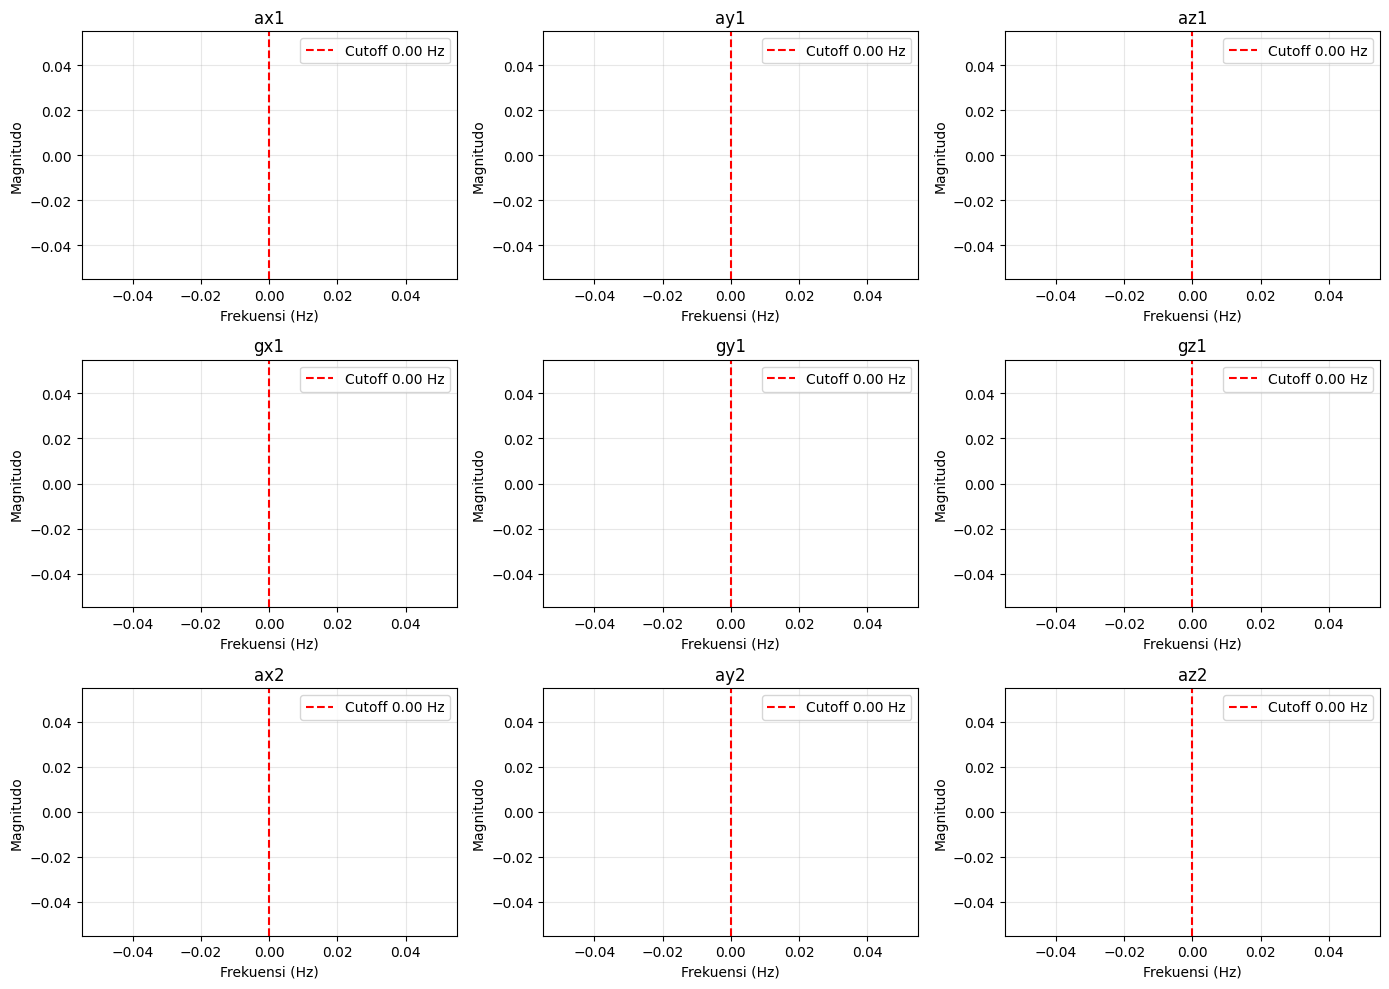


=== Rekomendasi Parameter Filter ===
Butterworth low-pass cutoff: berdasarkan FFT, disarankan sekitar 0.00 Hz
   (rentang: 0.00 - 0.00 Hz)
Kalman filter:
   Measurement variance (R) ≈ 0.390268 (gunakan nilai sekitar ini)
   Process variance (Q) ≈ 0.010000 (gunakan nilai sekitar ini)


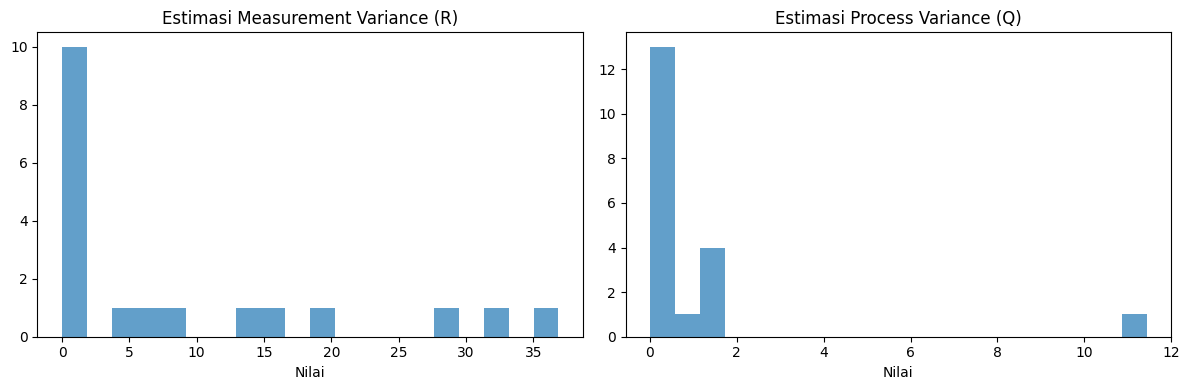

In [15]:
# Cell Analisis Frekuensi dan Noise untuk Filter (sebelum outlier detection)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.signal import periodogram

# ====================================================
# 1. Hitung frekuensi sampling dari timestamp
# ====================================================
# Hitung sampling frequency dari timestamp (sama seperti di sel FFT)
if 'epoch_ms' in df.columns:
    timestamps = df['epoch_ms'].values
elif 'ts_millis' in df.columns:
    timestamps = df['ts_millis'].values
else:
    timestamps = np.arange(len(df))

diffs = np.diff(timestamps) / 1000.0  # dalam detik
median_dt = np.median(diffs)
sampling_freq = 1.0 / median_dt if median_dt > 0 else 50.0
print(f"Frekuensi sampling yang digunakan: {sampling_freq:.2f} Hz")

# ====================================================
# 2. Pilih kolom sensor numerik (abaikan label, subject_id, dll)
# ====================================================
ignore_cols = ['subject_id', 'nama', 'date', 'time', 'epoch_ms', 'ts_millis',
               'source_file', 'datetime', 'label', 'label_encoded']
sensor_cols = [c for c in df.columns if c not in ignore_cols and np.issubdtype(df[c].dtype, np.number)]

print(f"\nKolom sensor yang dianalisis: {sensor_cols}")

# ====================================================
# 3. Analisis FFT untuk setiap sensor (ambil sampel 2048 points untuk efisiensi)
# ====================================================
n_fft = min(2048, len(df))
freqs = fftfreq(n_fft, d=median_dt)
pos_mask = freqs > 0

# Simpan rekomendasi cutoff untuk setiap sensor
cutoff_recommendations = {}

plt.figure(figsize=(14, 10))
for i, col in enumerate(sensor_cols[:9]):  # maksimal 9 subplot
    data = df[col].values[:n_fft]
    # Detrend sederhana
    data = data - np.mean(data)
    # FFT
    fft_vals = np.abs(fft(data))[:n_fft//2]
    f = freqs[:n_fft//2]

    # Cari frekuensi di mana 95% energi berada
    psd = fft_vals**2
    cumulative_energy = np.cumsum(psd) / np.sum(psd)
    cutoff_idx = np.searchsorted(cumulative_energy, 0.95)
    cutoff_freq = f[cutoff_idx] if cutoff_idx < len(f) else f[-1]
    cutoff_recommendations[col] = cutoff_freq

    plt.subplot(3, 3, i+1)
    plt.plot(f, fft_vals, linewidth=0.8)
    plt.axvline(cutoff_freq, color='r', linestyle='--', label=f'Cutoff {cutoff_freq:.2f} Hz')
    plt.title(f'{col}')
    plt.xlabel('Frekuensi (Hz)')
    plt.ylabel('Magnitudo')
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()

# ====================================================
# 4. Estimasi noise variance (R) dan process variance (Q) untuk Kalman
# ====================================================
# Metode: gunakan differencing orde pertama untuk estimasi noise
# Asumsi: sinyal = state + noise, state berubah lambat
noise_vars = []
process_vars = []

for col in sensor_cols:
    data = df[col].dropna().values
    if len(data) < 10:
        continue
    # Estimasi noise: variansi dari high-pass residual (selisih orde pertama)
    diff = np.diff(data)
    # Asumsikan perubahan state lambat, noise mendominasi pada diff
    # Estimasi R = variansi dari diff / 2 (karena diff = noise_t+1 - noise_t)
    R_est = np.var(diff) / 2.0
    # Estimasi Q: variansi dari perubahan state yang dihaluskan (low-pass)
    # Alternatif: Q = variansi dari perubahan sinyal setelah smoothing
    # Di sini kita gunakan variansi dari sinyal original dikurangi estimasi noise
    Q_est = max(0.01, np.var(data) - R_est)  # ensure positive
    noise_vars.append(R_est)
    process_vars.append(Q_est)

# Rata-rata rekomendasi
median_R = np.median(noise_vars) if noise_vars else 1e-2
median_Q = np.median(process_vars) if process_vars else 1e-5

print(f"\n=== Rekomendasi Parameter Filter ===")
print(f"Butterworth low-pass cutoff: berdasarkan FFT, disarankan sekitar {np.median(list(cutoff_recommendations.values())):.2f} Hz")
print(f"   (rentang: {min(cutoff_recommendations.values()):.2f} - {max(cutoff_recommendations.values()):.2f} Hz)")
print(f"Kalman filter:")
print(f"   Measurement variance (R) ≈ {median_R:.6f} (gunakan nilai sekitar ini)")
print(f"   Process variance (Q) ≈ {median_Q:.6f} (gunakan nilai sekitar ini)")

# ====================================================
# 5. Visualisasi distribusi noise dan sinyal (opsional)
# ====================================================
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.hist(noise_vars, bins=20, alpha=0.7)
plt.title('Estimasi Measurement Variance (R)')
plt.xlabel('Nilai')
plt.subplot(1,2,2)
plt.hist(process_vars, bins=20, alpha=0.7)
plt.title('Estimasi Process Variance (Q)')
plt.xlabel('Nilai')
plt.tight_layout()
plt.show()

# Preprocessing

## Split Data Train-Test

In [16]:
# # Cell Preprocessing 1: Split data menjadi train dan test
# from sklearn.model_selection import train_test_split

# split_idx = int(len(X) * 0.8)
# X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
# y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# print(f"Train: {X_train.shape}, Test: {X_test.shape}")
# print("Distribusi y_train:", y_train.value_counts(normalize=True).to_dict())
# print("Distribusi y_test:", y_test.value_counts(normalize=True).to_dict())

## Filtering

In [17]:
# Cell Preprocessing: Filtering (Kalman & Butterworth)
# Place this cell BEFORE outlier detection (after cleaning, before windowing)

from scipy.signal import butter, filtfilt, lfilter
import numpy as np

def butterworth_filter_causal(data, cutoff, fs, order=4, btype='low'):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype=btype, analog=False)
    # lfilter -> causal (hanya data masa lalu)
    return lfilter(b, a, data)

def kalman_filter_1d(data, process_variance=1e-5, measurement_variance=1e-2):
    """
    Simple 1D Kalman filter for smoothing.

    Parameters:
    data (array): 1D signal
    process_variance (float): Q - process noise covariance
    measurement_variance (float): R - measurement noise covariance

    Returns:
    filtered (array): filtered signal
    """
    n = len(data)
    filtered = np.zeros(n)
    # Initial state estimate and error covariance
    x_est = data[0]
    P_est = 1.0

    for i in range(n):
        # Prediction
        x_pred = x_est
        P_pred = P_est + process_variance

        # Update
        K = P_pred / (P_pred + measurement_variance)  # Kalman gain
        x_est = x_pred + K * (data[i] - x_pred)
        P_est = (1 - K) * P_pred
        filtered[i] = x_est

    return filtered

# ========== USER ADJUSTABLE PARAMETERS ==========
# --- Butterworth settings ---
use_butterworth = False         # Set False to skip
butter_cutoff = 5.0            # Cutoff frequency (Hz)
butter_order = 5               # Filter order

# --- Kalman settings ---
use_kalman = False              # Set False to skip
kalman_process_var = 0.001      # Process noise variance
kalman_measurement_var = 0.1  # Measurement noise variance

# ================================================

# # Apply filters to each numeric column (excluding label)
# numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
# # Note: X here is the feature DataFrame after cleaning, before windowing (time series)

# if use_butterworth or use_kalman:
#     print("Menerapkan filter ke setiap kolom numerik...")
#     for col in numeric_cols:
#         data = X_train[col].values
#         if use_butterworth:
#             data = butterworth_filter_causal(data, butter_cutoff, sampling_freq, butter_order)
#         if use_kalman:
#             data = kalman_filter_1d(data, kalman_process_var, kalman_measurement_var)
#         X_train[col] = data
#     print("Filter selesai diterapkan.")
# else:
#     print("Tidak ada filter yang diterapkan.")


In [18]:
# # Cell Perbandingan Sebelum dan Sesudah Filtering (tanpa modifikasi data)

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # ------------------------------------------------------------------
# # 1. Ambil data asli (sebelum filtering) dari df_clean
# #    Asumsi: df_clean masih berisi nilai sensor asli (belum difilter)
# #    dan X adalah DataFrame hasil filtering (sudah dimodifikasi)
# # ------------------------------------------------------------------
# # Kolom sensor yang digunakan dalam filtering (numeric_cols)
# numeric_cols = X_train.columns.tolist()  # karena X setelah filtering

# # Buat DataFrame asli dari df_clean hanya untuk kolom yang sama
# if 'df_clean' in globals():
#     original_data = df_clean[numeric_cols].copy()
#     print("Data asli (sebelum filtering) diambil dari df_clean.")
# else:
#     # fallback: jika df_clean tidak ada, coba gunakan X_original (jika ada)
#     if 'X_original' in globals():
#         original_data = X[numeric_cols].copy()
#         print("Data asli (sebelum filtering) diambil dari X_original.")
#     else:
#         raise NameError("Tidak ditemukan data asli (df_clean atau X_original).")

# # Data setelah filtering sudah ada di X
# filtered_data = X[numeric_cols].copy()
# print(f"Data setelah filtering diambil dari X (shape: {filtered_data.shape})")

# # ------------------------------------------------------------------
# # 2. Pilih beberapa kolom sensor untuk visualisasi (maksimal 6)
# # ------------------------------------------------------------------
# sample_cols = numeric_cols[:6]  # ambil 6 kolom pertama
# n_cols = len(sample_cols)

# # ------------------------------------------------------------------
# # 3. Plot perbandingan sinyal (500 sampel pertama)
# # ------------------------------------------------------------------
# fig, axes = plt.subplots(n_cols, 2, figsize=(14, 3*n_cols))
# if n_cols == 1:
#     axes = axes.reshape(1, -1)

# for i, col in enumerate(sample_cols):
#     # Sinyal asli dan setelah filter (500 poin pertama)
#     orig = original_data[col].values[:500]
#     filt = filtered_data[col].values[:500]

#     # Plot sinyal asli
#     axes[i, 0].plot(orig, label='Original', alpha=0.6, linewidth=0.8)
#     axes[i, 0].set_title(f'{col} - Original (sebelum filter)')
#     axes[i, 0].set_xlabel('Sampel ke-')
#     axes[i, 0].set_ylabel('Nilai')
#     axes[i, 0].legend()
#     axes[i, 0].grid(True, alpha=0.3)

#     # Plot sinyal setelah filter
#     axes[i, 1].plot(filt, label='Filtered', color='orange', alpha=0.6, linewidth=0.8)
#     axes[i, 1].set_title(f'{col} - Setelah Filter (Butterworth+Kalman)')
#     axes[i, 1].set_xlabel('Sampel ke-')
#     axes[i, 1].set_ylabel('Nilai')
#     axes[i, 1].legend()
#     axes[i, 1].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# # ------------------------------------------------------------------
# # 4. Statistik ringkasan (mean, std, min, max) untuk semua kolom
# # ------------------------------------------------------------------
# stats_orig = original_data.describe().T[['mean', 'std', 'min', 'max']]
# stats_filt = filtered_data.describe().T[['mean', 'std', 'min', 'max']]

# # Gabungkan untuk perbandingan
# stats_comp = pd.DataFrame({
#     'mean_orig': stats_orig['mean'],
#     'mean_filt': stats_filt['mean'],
#     'std_orig': stats_orig['std'],
#     'std_filt': stats_filt['std'],
#     'min_orig': stats_orig['min'],
#     'min_filt': stats_filt['min'],
#     'max_orig': stats_orig['max'],
#     'max_filt': stats_filt['max']
# })

# print("\n=== PERBANDINGAN STATISTIK (seluruh kolom) ===")
# print(stats_comp.round(4))

# # Hitung persen perubahan standar deviasi (indikator penurunan noise)
# stats_comp['std_change_%'] = ((stats_comp['std_filt'] - stats_comp['std_orig']) / stats_comp['std_orig']) * 100
# print("\n=== PERSENTASE PERUBAHAN STANDAR DEVIASI ===")
# print(stats_comp['std_change_%'].round(2))

# # ------------------------------------------------------------------
# # 5. Visualisasi distribusi selisih (original - filtered) untuk menilai noise
# # ------------------------------------------------------------------
# fig, axes = plt.subplots(2, 3, figsize=(15, 8))
# axes = axes.flatten()
# for idx, col in enumerate(sample_cols):
#     diff = original_data[col].values - filtered_data[col].values
#     axes[idx].hist(diff, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
#     axes[idx].set_title(f'{col} - Selisih (Original - Filtered)')
#     axes[idx].set_xlabel('Selisih')
#     axes[idx].set_ylabel('Frekuensi')
#     axes[idx].grid(True, alpha=0.3)
# # Matikan axis yang tidak terpakai
# for j in range(len(sample_cols), len(axes)):
#     axes[j].set_visible(False)
# plt.tight_layout()
# plt.show()

# # ------------------------------------------------------------------
# # 6. Ringkasan pengaruh filtering (opsional)
# # ------------------------------------------------------------------
# print("\n=== KESIMPULAN AWAL ===")
# print(f"Rata-rata perubahan standar deviasi: {stats_comp['std_change_%'].mean():.2f}%")
# if stats_comp['std_change_%'].mean() < 0:
#     print("Filtering secara umum mengurangi variabilitas sinyal (noise berkurang).")
# else:
#     print("Filtering tidak secara konsisten mengurangi variabilitas; periksa parameter.")

## Time-Window

## Scaling Fitur

In [19]:
# # Cell Preprocessing 2: Standarisasi fitur numerik (StandardScaler)

# # Standarisasi fitur numerik (X_train)

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train_win)
# X_test_scaled = scaler.transform(X_test_win)

# # Konversi kembali ke DataFrame (opsional, untuk kemudahan)
# X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_win.columns, index=X_train_win.index)
# X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_win.columns, index=X_test_win.index)

# print("Contoh statistik X_train_scaled:")
# display(X_train_scaled.describe())

# Modelling LOSO

## Training

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd
import xgboost as xgb

# --- Simpan hasil tiap fold ---
lopo_results = []
all_y_true   = []
all_y_pred   = []
conf_matrices = {}

print(f"Memulai LOPO dengan {len(subjek_unik)} fold...")
print("="*60)

# Global variables to store the data from the last fold for hyperparameter tuning
global X_train_hp, y_train_hp, X_test_hp, y_test_hp, scaler_hp, feature_names_hp
X_train_hp, y_train_hp, X_test_hp, y_test_hp, scaler_hp, feature_names_hp = None, None, None, None, None, None

# Variabel untuk menyimpan model terakhir dan data train (untuk feature importance)
xgb_final_model = None # Changed from rf_model to xgb_final_model
X_train_last_fold_for_features = None # To store X_train_processed for feature names

for fold_idx, test_subject in enumerate(subjek_unik):
    print(f"\nProcessing Fold {fold_idx+1}/{len(subjek_unik)} - Testing on: {test_subject}")

    # --- 1. Split berdasarkan subjek ---
    train_mask = groups != test_subject
    test_mask   = groups == test_subject

    X_train_current = X[train_mask].reset_index(drop=True)
    y_train_current = y[train_mask].reset_index(drop=True)
    X_test_current  = X[test_mask].reset_index(drop=True)
    y_test_current  = y[test_mask].reset_index(drop=True)

    # Debug: cek hasil split
    if len(X_train_current) == 0 or len(X_test_current) == 0:
        print(f"  ⚠ Fold {fold_idx+1} skipped: Raw data split resulted in empty train/test for {test_subject}")
        continue

    # --- 2. Gunakan data raw langsung (tanpa windowing) ---
    X_train_processed = X_train_current
    y_train_processed = y_train_current
    X_test_processed  = X_test_current
    y_test_processed  = y_test_current

    # Handle nilai inf/nan (praktek yang baik)
    X_train_processed = X_train_processed.replace([np.inf, -np.inf], np.nan).fillna(0)
    X_test_processed  = X_test_processed.replace([np.inf, -np.inf], np.nan).fillna(0)

    # Debug: cek data setelah preprocessing
    if len(X_train_processed) == 0 or len(X_test_processed) == 0:
        print(f"  ⚠ Fold {fold_idx+1} skipped: Processed data resulted in empty train/test for {test_subject}")
        continue

    # --- 3. Scaling (fit HANYA di train) ---
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_processed)
    X_test_scaled  = scaler.transform(X_test_processed)

    # --- 4. Training ---
    model = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train_scaled, y_train_processed)

    # --- 5. Evaluasi fold ini ---
    y_pred = model.predict(X_test_scaled)
    cm_fold = confusion_matrix(y_test_processed, y_pred, labels=[0, 1])
    acc    = accuracy_score(y_test_processed, y_pred)
    conf_matrices[test_subject] = cm_fold

    lopo_results.append({
        'fold'           : fold_idx + 1,
        'test_subject'   : test_subject,
        'n_train_samples': len(y_train_processed),
        'n_test_samples' : len(y_test_processed),
        'accuracy'       : acc
    })

    all_y_true.extend(y_test_processed.tolist())
    all_y_pred.extend(y_pred.tolist())

    print(f"  Fold {fold_idx+1:2d} | Test: {test_subject:<30s} | Acc: {acc:.4f} ({acc*100:.1f}%) | Train Samples: {len(y_train_processed)} | Test Samples: {len(y_test_processed)}")

    # Simpan model dan data train dari fold terakhir (untuk keperluan feature importance dan hyperparameter tuning)
    if fold_idx == len(subjek_unik) - 1:
        xgb_final_model = model
        X_train_last_fold_for_features = X_train_processed

        # Assign to global variables for hyperparameter tuning in the next cell
        X_train_hp = pd.DataFrame(X_train_scaled, columns=X_train_processed.columns)
        y_train_hp = y_train_processed
        X_test_hp = pd.DataFrame(X_test_scaled, columns=X_test_processed.columns)
        y_test_hp = y_test_processed
        scaler_hp = scaler
        feature_names_hp = X_train_processed.columns


print("="*60)

if not lopo_results:
    print("Warning: No folds were processed. 'all_y_true' and 'all_y_pred' are empty.")
else:
    results_df = pd.DataFrame(lopo_results)
    print("\nLOPO Summary:")
    print(results_df.to_string(index=False))


Memulai LOPO dengan 15 fold...

Processing Fold 1/15 - Testing on: alam.csv


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:21:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Fold  1 | Test: alam.csv                       | Acc: 0.7932 (79.3%) | Train Samples: 30529 | Test Samples: 1480

Processing Fold 2/15 - Testing on: alifi.csv


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:21:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Fold  2 | Test: alifi.csv                      | Acc: 0.6234 (62.3%) | Train Samples: 24890 | Test Samples: 7119

Processing Fold 3/15 - Testing on: arlin.csv


...

  Fold 13 | Test: sofi.csv                       | Acc: 0.8521 (85.2%) | Train Samples: 30751 | Test Samples: 1258

Processing Fold 14/15 - Testing on: sutri.csv


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:21:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Fold 14 | Test: sutri.csv                      | Acc: 0.8803 (88.0%) | Train Samples: 30514 | Test Samples: 1495

Processing Fold 15/15 - Testing on: yunda.csv


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:21:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Fold 15 | Test: yunda.csv                      | Acc: 0.8280 (82.8%) | Train Samples: 29590 | Test Samples: 2419

LOPO Summary:
 fold test_subject  n_train_samples  n_test_samples  accuracy
    1     alam.csv            30529            1480  0.793243
    2    alifi.csv            24890            7119  0.623402
    3    arlin.csv            29609            2400  0.737500
    4     ayuk.csv            30806            1203  0.879468
    5     dika.csv            29669            2340  0.702991
    6     dina.csv            31031             978  0.876278
    7   fathur.csv            30806            1203  0.527847
    8    fatim.csv            29595            2414  0.995029
    9   kelvin.csv            30511            1498  0.598798
   10    nahwa.csv            29575            2434  0.832786
   11     nisa.csv            30509            1500  0.878000
   12     rina.csv            29741            2268  0.209877
   13     sofi.csv            30751            1258  0.852146
  

In [21]:
# # Cell Model 3: Prediksi pada data test
# y_pred = rf_model.predict(X_test_scaled)
# y_pred_proba = rf_model.predict_proba(X_test_scaled)  # probabilitas untuk tiap kelas


## Evaluasi Model


📊 OVERALL EVALUATION METRICS (LOPO)
Overall Accuracy: 0.7213 (72.13%)

Overall Classification Report:
               precision    recall  f1-score   support

non-ergonomis       0.71      0.66      0.68     14657
    ergonomis       0.73      0.78      0.75     17352

     accuracy                           0.72     32009
    macro avg       0.72      0.72      0.72     32009
 weighted avg       0.72      0.72      0.72     32009


Overall Confusion Matrix (True vs Predicted):
          Non-Ergonomis   Ergonomis
Non-Ergonomis      9610    5047
Ergonomis          3875   13477


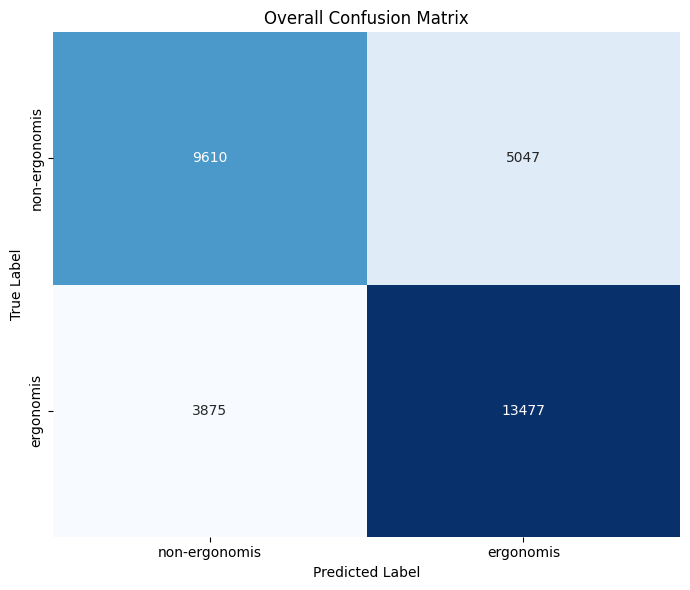

In [22]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define class labels for readability, matching the actual two classes (0 and 1) in label_mapping
# As per label_mapping: {'ergonomis': 1, 'non-ergonomis': 0}
# So, class 0 is 'non-ergonomis' and class 1 is 'ergonomis'
class_labels = ['non-ergonomis', 'ergonomis']

print("\n" + "="*70)
print("📊 OVERALL EVALUATION METRICS (LOPO)")
print("="*70)

# 1. Overall Accuracy
overall_accuracy = accuracy_score(all_y_true, all_y_pred)
print(f"Overall Accuracy: {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)\n")

# 2. Overall Classification Report (Precision, Recall, F1-score)
print("Overall Classification Report:")
# Ensure classification_report expects only the classes present (0 and 1)
print(classification_report(all_y_true, all_y_pred, target_names=class_labels, labels=[0, 1]))

# 3. Overall Confusion Matrix
# Ensure confusion_matrix expects only the classes present (0 and 1)
overall_cm = confusion_matrix(all_y_true, all_y_pred, labels=[0, 1])

print("\nOverall Confusion Matrix (True vs Predicted):")
print("          Non-Ergonomis   Ergonomis")
print(f"Non-Ergonomis     {overall_cm[0,0]:5d}   {overall_cm[0,1]:5d}")
print(f"Ergonomis         {overall_cm[1,0]:5d}   {overall_cm[1,1]:5d}")

# 4. Visualize Overall Confusion Matrix
plt.figure(figsize=(7, 6))
sns.heatmap(overall_cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Overall Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## Analisis Feature Importance


=== SELURUH FEATURE IMPORTANCE (diurutkan) ===
1. az: 0.242394
2. az1: 0.184837
3. ay: 0.139870
4. ax: 0.121088
5. ax1: 0.043137
6. az2: 0.036937
7. gy1: 0.033656
8. ay1: 0.030265
9. ay2: 0.028663
10. gz2: 0.019171
11. gy: 0.018985
12. gz: 0.016542
13. gy2: 0.015779
14. ax2: 0.015577
15. gx: 0.013863
16. gz1: 0.013403
17. gx1: 0.013114
18. gx2: 0.012718

=== DataFrame Feature Importance (10 teratas) ===
   feature  importance
14      az    0.242394
2      az1    0.184837
13      ay    0.139870
12      ax    0.121088
0      ax1    0.043137
8      az2    0.036937
4      gy1    0.033656
1      ay1    0.030265
7      ay2    0.028663
11     gz2    0.019171

Total fitur: 18


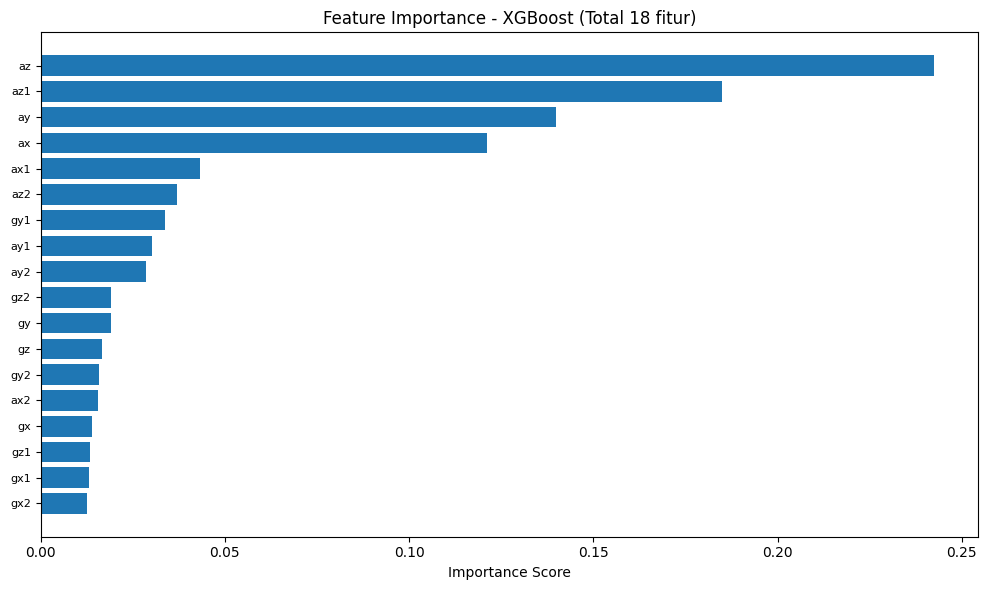

In [23]:
importances = xgb_final_model.feature_importances_
feature_names = X_train_last_fold_for_features.columns # Get column names from the DataFrame

# Urutkan berdasarkan importance descending
indices = np.argsort(importances)[::-1]

# ============================================
# OPSI 1: Tampilkan seluruh fitur dalam bentuk teks (print)
# ============================================
print("\n=== SELURUH FEATURE IMPORTANCE (diurutkan) ===")
for i, idx in enumerate(indices):
    print(f"{i+1}. {feature_names[idx]}: {importances[idx]:.6f}")

# ============================================
# OPSI 2: Simpan ke DataFrame untuk dilihat lebih mudah
# ============================
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\n=== DataFrame Feature Importance (10 teratas) ===")
print(importance_df.head(10))
print(f"\nTotal fitur: {len(importance_df)}")

# ============================================
# OPSI 3: Visualisasi SEMUA fitur (HATI-HATI jika fitur > 50)
# ============================
n_features = len(feature_names)
if n_features <= 50:
    # Ukuran figure disesuaikan dengan jumlah fitur (setiap fitur ~0.2 inch)
    plt.figure(figsize=(10, max(6, n_features * 0.2)))
    plt.barh(range(n_features), importances[indices], align='center')
    plt.yticks(range(n_features), [feature_names[i] for i in indices], fontsize=8)
    plt.xlabel('Importance Score')
    plt.title(f'Feature Importance - XGBoost (Total {n_features} fitur)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print(f"\nJumlah fitur terlalu banyak ({n_features}) untuk divisualisasikan dalam satu plot.")
    print("Gunakan 'importance_df' untuk melihat nilai importance secara detail.")


📊 VISUALISASI CONFUSION MATRIX PER SUBJECT (HEATMAP)


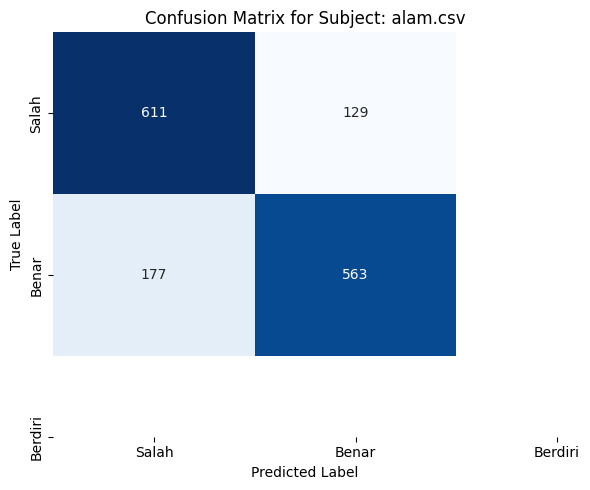

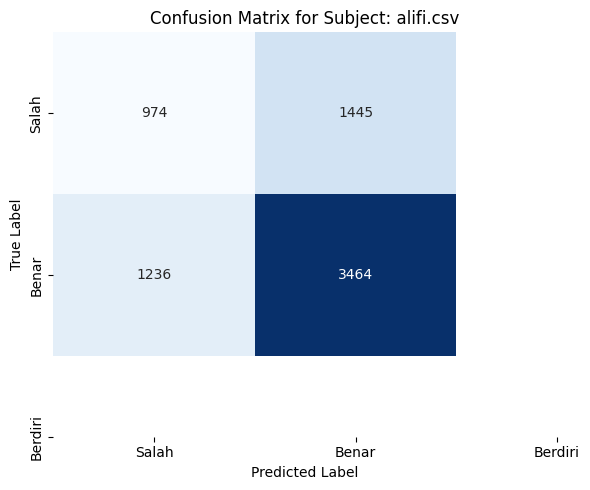

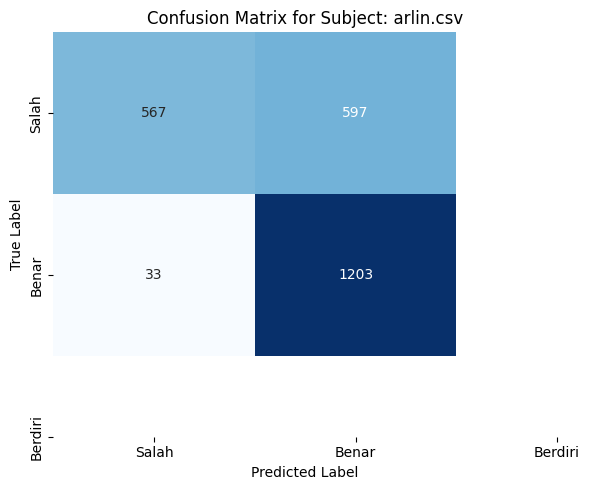

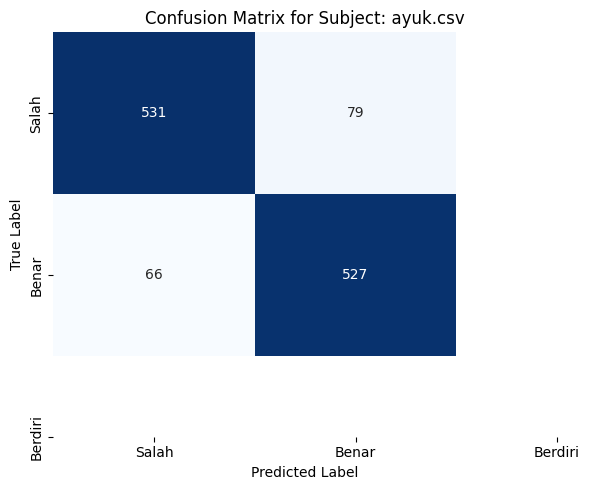

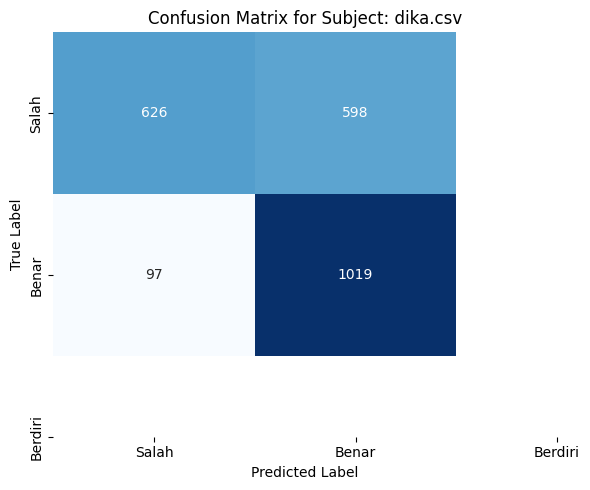

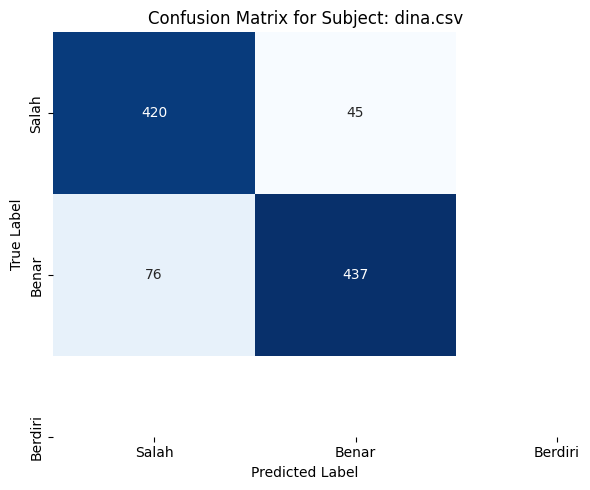

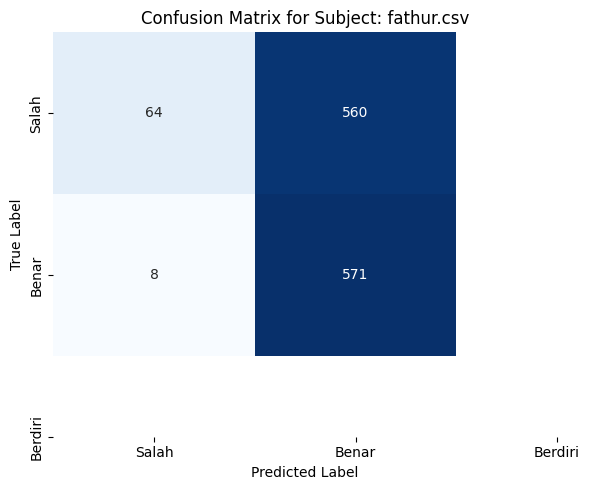

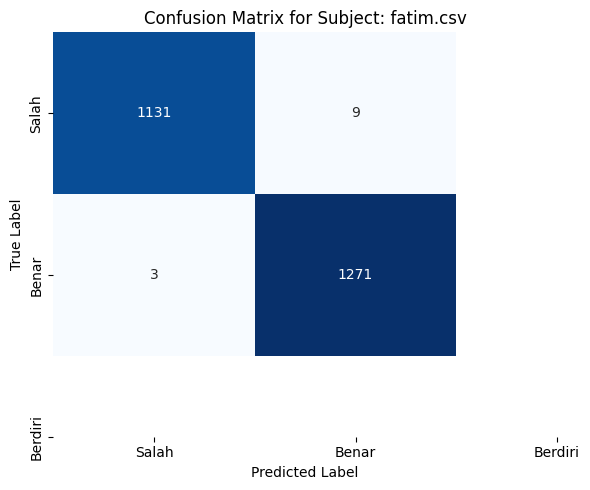

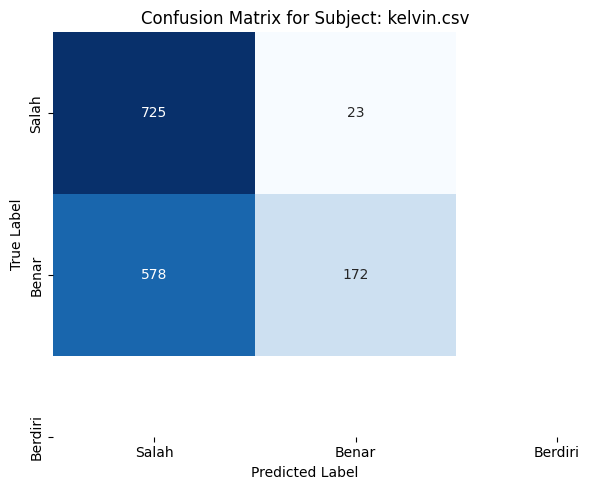

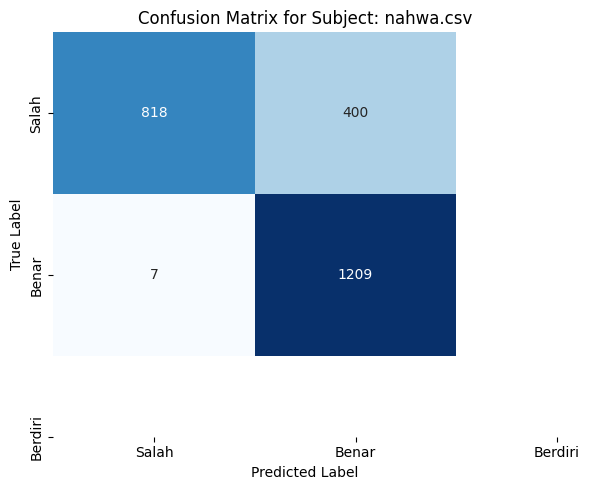

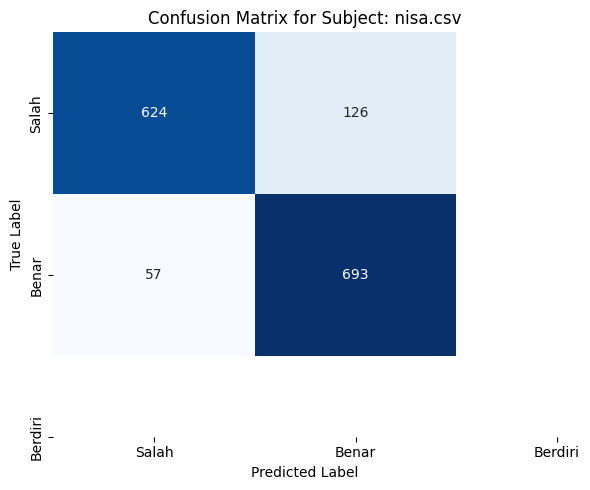

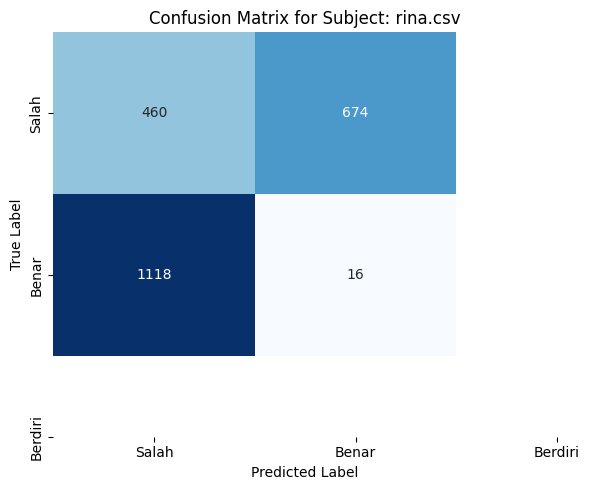

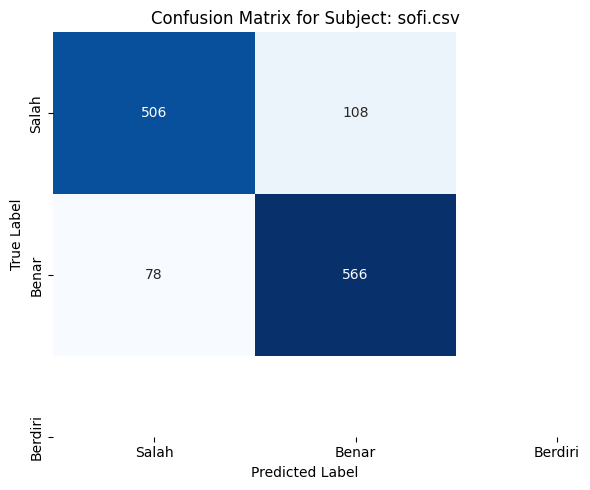

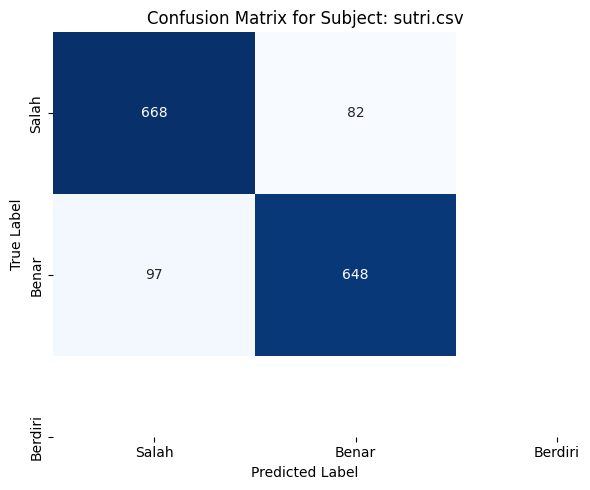

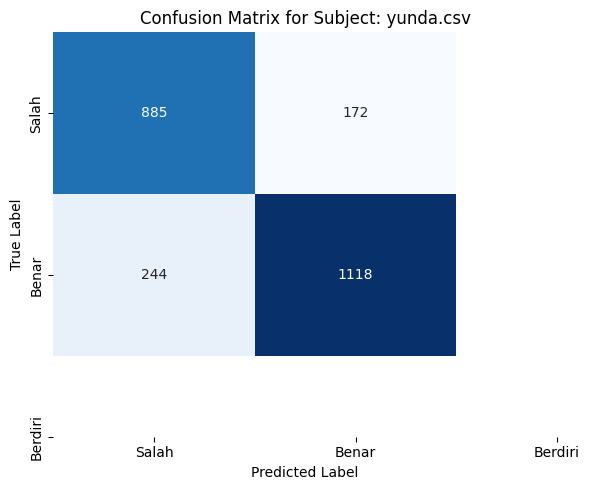

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define the class labels
class_labels = ['Salah', 'Benar', 'Berdiri']

print("\n" + "="*70)
print("📊 VISUALISASI CONFUSION MATRIX PER SUBJECT (HEATMAP)")
print("="*70)

# Iterate through each subject's confusion matrix and visualize it
for subject, cm in conf_matrices.items():
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title(f'Confusion Matrix for Subject: {subject}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()



=== SELURUH FEATURE IMPORTANCE (diurutkan) ===
1. az: 0.242394
2. az1: 0.184837
3. ay: 0.139870
4. ax: 0.121088
5. ax1: 0.043137
6. az2: 0.036937
7. gy1: 0.033656
8. ay1: 0.030265
9. ay2: 0.028663
10. gz2: 0.019171
11. gy: 0.018985
12. gz: 0.016542
13. gy2: 0.015779
14. ax2: 0.015577
15. gx: 0.013863
16. gz1: 0.013403
17. gx1: 0.013114
18. gx2: 0.012718

=== DataFrame Feature Importance (10 teratas) ===
   feature  importance
14      az    0.242394
2      az1    0.184837
13      ay    0.139870
12      ax    0.121088
0      ax1    0.043137
8      az2    0.036937
4      gy1    0.033656
1      ay1    0.030265
7      ay2    0.028663
11     gz2    0.019171

Total fitur: 18


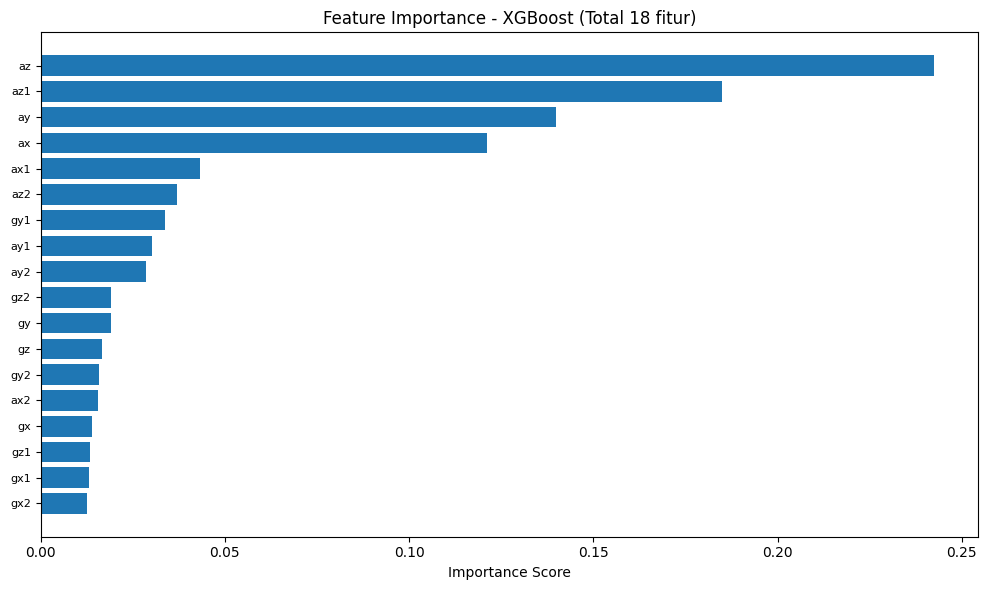

In [25]:
importances = xgb_final_model.feature_importances_
feature_names = X_train_last_fold_for_features.columns # Get column names from the DataFrame

# Urutkan berdasarkan importance descending
indices = np.argsort(importances)[::-1]

# ============================================
# OPSI 1: Tampilkan seluruh fitur dalam bentuk teks (print)
# ============================================
print("\n=== SELURUH FEATURE IMPORTANCE (diurutkan) ===")
for i, idx in enumerate(indices):
    print(f"{i+1}. {feature_names[idx]}: {importances[idx]:.6f}")

# ============================================
# OPSI 2: Simpan ke DataFrame untuk dilihat lebih mudah
# ============================
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\n=== DataFrame Feature Importance (10 teratas) ===")
print(importance_df.head(10))
print(f"\nTotal fitur: {len(importance_df)}")

# ============================================
# OPSI 3: Visualisasi SEMUA fitur (HATI-HATI jika fitur > 50)
# ============================
n_features = len(feature_names)
if n_features <= 50:
    # Ukuran figure disesuaikan dengan jumlah fitur (setiap fitur ~0.2 inch)
    plt.figure(figsize=(10, max(6, n_features * 0.2)))
    plt.barh(range(n_features), importances[indices], align='center')
    plt.yticks(range(n_features), [feature_names[i] for i in indices], fontsize=8)
    plt.xlabel('Importance Score')
    plt.title(f'Feature Importance - XGBoost (Total {n_features} fitur)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print(f"\nJumlah fitur terlalu banyak ({n_features}) untuk divisualisasikan dalam satu plot.")
    print("Gunakan 'importance_df' untuk melihat nilai importance secara detail.")


## Analisis

In [26]:
print(results_df.to_string(index=False))
print(f"\nRata-rata: {results_df['accuracy'].mean():.4f}")
print(f"Std Dev  : {results_df['accuracy'].std():.4f}")

# === CEK 2: Classification report per kelas ===
from sklearn.metrics import classification_report
print("\n", classification_report(
    all_y_true, all_y_pred,
    target_names=['non-ergonomis', 'ergonomis']
))

# === CEK 3: Frekuensi sampling ===
print(f"\nsampling_freq = {sampling_freq:.4f} Hz")

# === CEK 4: Distribusi kelas per subjek ===
print("\nDistribusi label per subjek:")
print(df_clean.groupby(['source_file','label'])['label'].count().unstack(fill_value=0))

# === CEK 5: Jumlah windows per subjek ===
print("\nJumlah sampel per subjek (test):")
for r in lopo_results:
    print(f"  {r['test_subject']:<30s}: {r['n_test_samples']:>4d} samples")

 fold test_subject  n_train_samples  n_test_samples  accuracy
    1     alam.csv            30529            1480  0.793243
    2    alifi.csv            24890            7119  0.623402
    3    arlin.csv            29609            2400  0.737500
    4     ayuk.csv            30806            1203  0.879468
    5     dika.csv            29669            2340  0.702991
    6     dina.csv            31031             978  0.876278
    7   fathur.csv            30806            1203  0.527847
    8    fatim.csv            29595            2414  0.995029
    9   kelvin.csv            30511            1498  0.598798
   10    nahwa.csv            29575            2434  0.832786
   11     nisa.csv            30509            1500  0.878000
   12     rina.csv            29741            2268  0.209877
   13     sofi.csv            30751            1258  0.852146
   14    sutri.csv            30514            1495  0.880268
   15    yunda.csv            29590            2419  0.828028

Rata-ra

## Simpan Model dan Output

In [27]:
# Cell Model 6: Simpan model, scaler, hasil evaluasi, dan info penggunaan model
import joblib
import json
import os
import pandas as pd # Import pandas for DataFrame creation

# ========== ATUR PATH PENYIMPANAN DI SINI ==========
SAVE_DIR = '/content/drive/MyDrive/Dataset Skripsi /OutputColabAnisa'
# ==================================================

# Buat folder jika belum ada
os.makedirs(SAVE_DIR, exist_ok=True)

# ==========================
# Simpan model dan scaler
# ==========================
joblib.dump(
    xgb_final_model,
    os.path.join(
        SAVE_DIR,
        'xgboost_model.pkl' # Changed to xgboost_model.pkl
    )
)

joblib.dump(
    scaler_hp,
    os.path.join(
        SAVE_DIR,
        'scaler.pkl'
    )
)

print(
    f"Model dan scaler disimpan di: {SAVE_DIR}"
)

# ==========================
# Simpan classification report
# ==========================
report = classification_report(
    all_y_true, # Use all_y_true
    all_y_pred, # Use all_y_pred
    target_names=[
        'non-ergonomis',
        'ergonomis'
    ],
    output_dict=True
)

with open(
    os.path.join(
        SAVE_DIR,
        'classification_report.json'
    ),
    'w'
) as f:
    json.dump(
        report,
        f,
        indent=4
    )

print(
    f"Classification report disimpan ke: "
    f"{SAVE_DIR}/classification_report.json"
)

# ==========================
# Simpan prediksi ke CSV
# ==========================
# Create a DataFrame from the aggregated true and predicted labels
hasil_prediksi = pd.DataFrame({
    'true_label': all_y_true,
    'predicted_label': all_y_pred
})

hasil_prediksi.to_csv(
    os.path.join(
        SAVE_DIR,
        'predictions.csv'
    ),
    index=False
)

print(
    f"Hasil prediksi disimpan ke: "
    f"{SAVE_DIR}/predictions.csv"
)

# ==========================
# Simpan informasi model ke TXT
# ==========================

info_model = f"""
INFORMASI MODEL XGBOOST
=============================

Nama Model:
xgboost_model.pkl

Scaler:
scaler.pkl

Jenis Model:
XGBoost Classifier

INPUT YANG DIPERLUKAN
---------------------
Model membutuhkan input berikut:

{list(feature_names_hp)}

Jumlah fitur:
{len(feature_names_hp)}

Catatan:
- Urutan input HARUS sama seperti daftar fitur di atas
- Data input harus melalui proses scaling
  menggunakan scaler.pkl sebelum prediksi
- Format input disarankan:
  DataFrame pandas atau array numerik

CONTOH ALUR PENGGUNAAN
---------------------

1. Load model:
   xgb_model = joblib.load(
       'xgboost_model.pkl'
   )

2. Load scaler:
   scaler = joblib.load(
       'scaler.pkl'
   )

3. Masukkan data baru

4. Lakukan scaling:
   data_scaled = scaler.transform(
       data_baru
   )

5. Prediksi:
   hasil = xgb_model.predict(
       data_scaled
   )

OUTPUT YANG DIHASILKAN
----------------------

0 = non-ergonomis
1 = ergonomis

Interpretasi:
- Output model berupa kelas numerik
- Gunakan mapping di atas
  untuk membaca hasil prediksi

File dibuat otomatis setelah training.
"""

with open(
    os.path.join(
        SAVE_DIR,
        'model_info.txt'
    ),
    'w',
    encoding='utf-8'
) as f:
    f.write(info_model)

print(
    f"Informasi model disimpan ke: "
    f"{SAVE_DIR}/model_info.txt"
)

Model dan scaler disimpan di: /content/drive/MyDrive/Dataset Skripsi /OutputColabAnisa
Classification report disimpan ke: /content/drive/MyDrive/Dataset Skripsi /OutputColabAnisa/classification_report.json
Hasil prediksi disimpan ke: /content/drive/MyDrive/Dataset Skripsi /OutputColabAnisa/predictions.csv
Informasi model disimpan ke: /content/drive/MyDrive/Dataset Skripsi /OutputColabAnisa/model_info.txt


# Hyperparameter

In [ ]:
import numpy as np
import joblib
import json
import os
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, ParameterSampler, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import randint, uniform
from tqdm.auto import tqdm

# ========== PARAMETER GRID ==========
# Parameter yang lebih luas
param_dist = {
    'n_estimators': randint(100, 800),
    'max_depth': [None] + list(range(30, 101, 10)),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7],
    'bootstrap': [True, False],
    'class_weight': ['balanced', 'balanced_subsample', None],
    'criterion': ['gini', 'entropy']
}

n_iter = 50
cv_folds = 5
total_fits = n_iter * cv_folds

print(f"Memulai Randomized Search dengan {n_iter} kombinasi parameter")
print(f"Cross-validation {cv_folds} folds → Total fit: {total_fits}")

# Generate random parameter samples
param_list = list(ParameterSampler(param_dist, n_iter=n_iter, random_state=42))

best_score = -np.inf
best_params = None
best_estimator = None
results = []

# Ensure the necessary variables are defined from the previous cell's last fold
# If the previous cell hasn't run or didn't set these, this will still raise an error
if 'X_train_hp' not in globals() or X_train_hp is None or y_train_hp is None or X_test_hp is None or y_test_hp is None:
    raise RuntimeError("X_train_hp, y_train_hp, X_test_hp, y_test_hp not defined. Please run the LOPO cell (UNztE4ML-pFH) first to prepare data for hyperparameter tuning.")

# Manual loop dengan progress bar
with tqdm(total=total_fits, desc="Progress fits", unit="fit") as pbar:
    for params in param_list:
        # Cross-validation untuk parameter ini
        model = RandomForestClassifier(random_state=42, n_jobs=-1, **params)
        # Use X_train_hp, y_train_hp for training
        cv_scores = cross_val_score(model, X_train_hp, y_train_hp, cv=cv_folds, scoring='accuracy')
        mean_score = np.mean(cv_scores)

        # Update progress bar sebanyak cv_folds
        pbar.update(cv_folds)

        # Simpan hasil
        results.append({
            'params': params,
            'mean_score': mean_score,
            'std_score': np.std(cv_scores)
        })

        # Jika lebih baik, simpan sebagai best
        if mean_score > best_score:
            best_score = mean_score
            best_params = params
            # Latih ulang model dengan semua data training (X_train_hp, y_train_hp)
            best_estimator = RandomForestClassifier(random_state=42, n_jobs=-1, **params)
            best_estimator.fit(X_train_hp, y_train_hp)
            pbar.set_postfix(current_best=best_score)

print("\n" + "="*50)
print("HASIL RANDOMIZED SEARCH")
print("="*50)
print(f"Parameter terbaik: {best_params}")
print(f"Skor validasi terbaik (CV mean accuracy): {best_score:.4f}")

# ====================================================
# EVALUASI MODEL TERBAIK PADA DATA TEST
# ====================================================
# Use X_test_hp, y_test_hp for evaluation
y_pred_best = best_estimator.predict(X_test_hp)
accuracy_best = accuracy_score(y_test_hp, y_pred_best)

print(f"\nAkurasi pada test set: {accuracy_best:.4f} ({accuracy_best*100:.2f}%)")
print("\nClassification Report - Model Terbaik:")
# Corrected target_names for binary classification, use y_test_hp
print(classification_report(y_test_hp, y_pred_best,
                          target_names=['non-ergonomis', 'ergonomis']))

# Use y_test_hp for confusion matrix
cm_best = confusion_matrix(y_test_hp, y_pred_best)
print("\nConfusion Matrix:")
print(cm_best)

# ====================================================
# PERBANDINGAN
# ====================================================
print("\n" + "="*50)
print("PERBANDINGAN DENGAN MODEL DEFAULT")
print("="*50)
# Use overall_accuracy from LOPO evaluation for comparison
print(f"Akurasi model default: {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")
print(f"Akurasi model terbaik: {accuracy_best:.4f} ({accuracy_best*100:.2f}%)")
print(f"Peningkatan: {(accuracy_best - overall_accuracy)*100:.2f}% ")

# ====================================================
# SIMPAN HASIL
# ====================================================
SAVE_DIR = '/content/drive/MyDrive/Dataset Skripsi /OutputColab'
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(best_estimator, os.path.join(SAVE_DIR, 'random_forest_best.pkl'))
print(f"\nModel terbaik disimpan di: {SAVE_DIR}/random_forest_best.pkl")

with open(os.path.join(SAVE_DIR, 'best_params.json'), 'w') as f:
    json.dump(best_params, f, indent=4)

# Simpan semua hasil CV
results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(SAVE_DIR, 'cv_results.csv'), index=False)

eval_results = {
    'best_params': best_params,
    'best_cv_score': best_score,
    'test_accuracy': accuracy_best,
    'classification_report': classification_report(
        y_test_hp, y_pred_best, # Use y_test_hp
        target_names=['non-ergonomis', 'ergonomis'], # Corrected target_names
        output_dict=True
    ),
    'confusion_matrix': cm_best.tolist()
}
with open(os.path.join(SAVE_DIR, 'tuning_results.json'), 'w') as f:
    json.dump(eval_results, f, indent=4)

# Prediksi
# Use feature_names_hp which holds the feature names from the last LOPO fold's processed data
pred_df = pd.DataFrame(X_test_hp, columns=feature_names_hp)
pred_df['true_label'] = y_test_hp.values # Use y_test_hp
pred_df['predicted_label'] = y_pred_best
pred_df.to_csv(os.path.join(SAVE_DIR, 'predictions_best.csv'), index=False)

print("\n=== PROSES HYPERPARAMETER TUNING SELESAI ===")

Memulai Randomized Search dengan 50 kombinasi parameter
Cross-validation 5 folds → Total fit: 250


Progress fits:   0%|          | 0/250 [00:00<?, ?fit/s]


HASIL RANDOMIZED SEARCH
Parameter terbaik: {'bootstrap': True, 'class_weight': None, 'criterion': 'gini', 'max_depth': 100, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 15, 'n_estimators': 341}
Skor validasi terbaik (CV mean accuracy): 0.6129

Akurasi pada test set: 0.7094 (70.94%)

Classification Report - Model Terbaik:
               precision    recall  f1-score   support

non-ergonomis       0.65      0.71      0.68      1057
    ergonomis       0.76      0.71      0.73      1362

     accuracy                           0.71      2419
    macro avg       0.71      0.71      0.71      2419
 weighted avg       0.71      0.71      0.71      2419


Confusion Matrix:
[[752 305]
 [398 964]]

PERBANDINGAN DENGAN MODEL DEFAULT
Akurasi model default: 0.7213 (72.13%)
Akurasi model terbaik: 0.7094 (70.94%)
Peningkatan: -1.19% 

Model terbaik disimpan di: /content/drive/MyDrive/Dataset Skripsi /OutputColab/random_forest_best.pkl

=== PROSES HYPERPARAMETER TUNING SELESAI